**<font size="6">Challenge 1</font>**

**<font size="5">MSc in Health Informatics - UniSR - A.Y. 2024-2025</font>**

Giulia Caffi

---

<font size="4">“Exploring the Impact of Natural Environments on Birth Out-comes: A Research Proposal Exercise”</font>

# **Libraries**

In [1]:
import pandas as pd
pd.options.display.float_format = '{:.2f}'.format

In [2]:
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import numpy as np

In [4]:
from sklearn import model_selection
from sklearn.preprocessing import PolynomialFeatures, StandardScaler, MinMaxScaler, OneHotEncoder
from sklearn.feature_selection import SelectKBest, f_regression
from sklearn.metrics import roc_curve, roc_auc_score, confusion_matrix, r2_score, mean_squared_error, classification_report
from sklearn.model_selection import train_test_split

In [5]:
import statsmodels.api as sm
import statsmodels.stats.api as sms
from statsmodels.stats.diagnostic import het_breuschpagan
from statsmodels.stats.stattools import durbin_watson
from statsmodels.stats.outliers_influence import variance_inflation_factor
import statsmodels.formula.api as smf

In [6]:
import scipy.stats as stats
from scipy.stats import kurtosis, skew, shapiro, chi2_contingency, levene, kruskal, ttest_ind, ttest_ind, pearsonr

In [7]:
!pip install gpboost -U
import gpboost as gpb

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 4.5/4.5 MB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 364.4/364.4 kB 21.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.5/233.5 kB 13.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 78.6/78.6 kB 5.6 MB/s eta 0:00:00


In [8]:
from tqdm.notebook import tqdm

In [9]:
np.random.seed(1234)

# **Load dataset**

In [10]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [11]:
PATH = '/content/drive/MyDrive/statistica/'
df = pd.read_csv(PATH + 'dataset_challenge_def.csv')

In [12]:
df

,Maternal_age,Parity,NDVI_100m,NDVI_300m,NDVI_500m,Residential_distance_to_green_space,Residential_distance_to_blue_space,NO2,PM2.5,Birth_weight_modelled,Pre_term,Child_sex,Maternal_education,Maternal_ethnicity,Area_level_deprivation,Maternal_smoking,Maternal_alcohol_consumption,Accessibility_to_green_space,Accessibility_to_blue_space,Cohort
0,28.03,Multi,0.54,0.32,0.49,365.20,1051.50,38.81,18.80,2057.19,1,Boy,High,Western,Low,Yes,Yes,Yes,No,A
1,37.09,Single,0.27,0.20,0.48,277.60,941.83,23.79,14.35,3036.11,0,Girl,Medium,Non-Western,Low,No,No,Yes,No,A
2,32.34,Multi,0.39,0.48,0.34,289.12,2334.22,25.14,17.32,1680.52,1,Girl,High,Western,Medium,No,No,Yes,No,A
3,30.65,Single,0.39,0.58,0.55,159.52,1154.24,30.66,12.42,3280.88,0,Boy,High,Western,Low,No,No,Yes,Yes,A
4,24.86,Multi,0.37,0.28,0.29,394.88,1798.14,22.26,15.76,2296.78,0,Boy,Medium,Western,Low,No,No,Yes,Yes,A
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4440,32.44,Single,0.26,0.20,0.13,243.16,2399.25,24.25,25.12,2038.71,1,Boy,High,Western,Medium,No,Yes,Yes,No,K
4441,31.27,Single,-0.00,0.31,0.35,289.74,2713.54,63.22,29.43,842.00,1,Girl,Medium,Non-Western,High,No,Yes,Yes,No,K
4442,34.37,Multi,0.15,0.23,0.27,277.94,550.61,22.55,32.28,2592.87,1,Boy,Medium,Western,Medium,No,Yes,Yes,No,K
4443,32.47,Single,0.20,0.27,0.29,61.51,536.72,52.00,23.31,2428.95,1,Boy,Medium,Western,Low,No,No,Yes,No,K


# **Descriptive statistics**

In [13]:
df.shape

(4445, 20)

In [14]:
df.columns

Index(['Maternal_age', 'Parity', 'NDVI_100m', 'NDVI_300m', 'NDVI_500m',
       'Residential_distance_to_green_space',
       'Residential_distance_to_blue_space', 'NO2', 'PM2.5',
       'Birth_weight_modelled', 'Pre_term', 'Child_sex', 'Maternal_education',
       'Maternal_ethnicity', 'Area_level_deprivation', 'Maternal_smoking',
       'Maternal_alcohol_consumption', 'Accessibility_to_green_space',
       'Accessibility_to_blue_space', 'Cohort'],
      dtype='object')

In [15]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 4445 entries, 0 to 4444
Data columns (total 20 columns):
 #   Column                               Non-Null Count  Dtype  
---  ------                               --------------  -----  
 0   Maternal_age                         4445 non-null   float64
 1   Parity                               4445 non-null   object 
 2   NDVI_100m                            4445 non-null   float64
 3   NDVI_300m                            4445 non-null   float64
 4   NDVI_500m                            4445 non-null   float64
 5   Residential_distance_to_green_space  4445 non-null   float64
 6   Residential_distance_to_blue_space   4445 non-null   float64
 7   NO2                                  4445 non-null   float64
 8   PM2.5                                4445 non-null   float64
 9   Birth_weight_modelled                4445 non-null   float64
 10  Pre_term                             4445 non-null   int64  
 11  Child_sex                     

In [16]:
cat_vars = ['Parity', 'Pre_term', 'Child_sex',  'Maternal_education',  'Maternal_ethnicity',  'Area_level_deprivation', 'Maternal_smoking', 'Maternal_alcohol_consumption', 'Accessibility_to_green_space', 'Accessibility_to_blue_space', 'Cohort']
num_vars = ['Maternal_age', 'NDVI_100m', 'NDVI_300m', 'NDVI_500m', 'Residential_distance_to_green_space', 'Residential_distance_to_blue_space', 'NO2', 'PM2.5', 'Birth_weight_modelled']

## Categorical variables

### Frequencies

Absolute frequencies

In [17]:
for column_name in cat_vars:
    print(df[column_name].value_counts())

Parity
Single    2373
Multi     2072
Name: count, dtype: int64
Pre_term
0    2646
1    1799
Name: count, dtype: int64
Child_sex
Boy     2229
Girl    2216
Name: count, dtype: int64
Maternal_education
High      2308
Low       1345
Medium     792
Name: count, dtype: int64
Maternal_ethnicity
Western        3476
Non-Western     969
Name: count, dtype: int64
Area_level_deprivation
High      1927
Low       1736
Medium     782
Name: count, dtype: int64
Maternal_smoking
No     3646
Yes     799
Name: count, dtype: int64
Maternal_alcohol_consumption
Yes    2270
No     2175
Name: count, dtype: int64
Accessibility_to_green_space
Yes    3302
No     1143
Name: count, dtype: int64
Accessibility_to_blue_space
No     3494
Yes     951
Name: count, dtype: int64
Cohort
J    1072
C     658
B     562
D     527
I     445
F     409
A     359
H     202
G      98
E      70
K      43
Name: count, dtype: int64


Relative frequencies

In [18]:
for column_name in cat_vars:
    print(df[column_name].value_counts(normalize=True))

Parity
Single   0.53
Multi    0.47
Name: proportion, dtype: float64
Pre_term
0   0.60
1   0.40
Name: proportion, dtype: float64
Child_sex
Boy    0.50
Girl   0.50
Name: proportion, dtype: float64
Maternal_education
High     0.52
Low      0.30
Medium   0.18
Name: proportion, dtype: float64
Maternal_ethnicity
Western       0.78
Non-Western   0.22
Name: proportion, dtype: float64
Area_level_deprivation
High     0.43
Low      0.39
Medium   0.18
Name: proportion, dtype: float64
Maternal_smoking
No    0.82
Yes   0.18
Name: proportion, dtype: float64
Maternal_alcohol_consumption
Yes   0.51
No    0.49
Name: proportion, dtype: float64
Accessibility_to_green_space
Yes   0.74
No    0.26
Name: proportion, dtype: float64
Accessibility_to_blue_space
No    0.79
Yes   0.21
Name: proportion, dtype: float64
Cohort
J   0.24
C   0.15
B   0.13
D   0.12
I   0.10
F   0.09
A   0.08
H   0.05
G   0.02
E   0.02
K   0.01
Name: proportion, dtype: float64


### Barplots

In [19]:
colors = ['#baddf5', '#cc2b2b']

<ipython-input-20-4d52b57f6bcb>:5: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(data=df, x=cat_vars[i], palette=colors, hue=cat_vars[i], legend=False, ax=ax[i])
<ipython-input-20-4d52b57f6bcb>:5: UserWarning: 
The palette list has fewer values (2) than needed (3) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(data=df, x=cat_vars[i], palette=colors, hue=cat_vars[i], legend=False, ax=ax[i])
<ipython-input-20-4d52b57f6bcb>:5: UserWarning: 
The palette list has fewer values (2) than needed (11) and will cycle, which may produce an uninterpretable plot.
  sns.countplot(data=df, x=cat_vars[i], palette=colors, hue=cat_vars[i], legend=False, ax=ax[i])


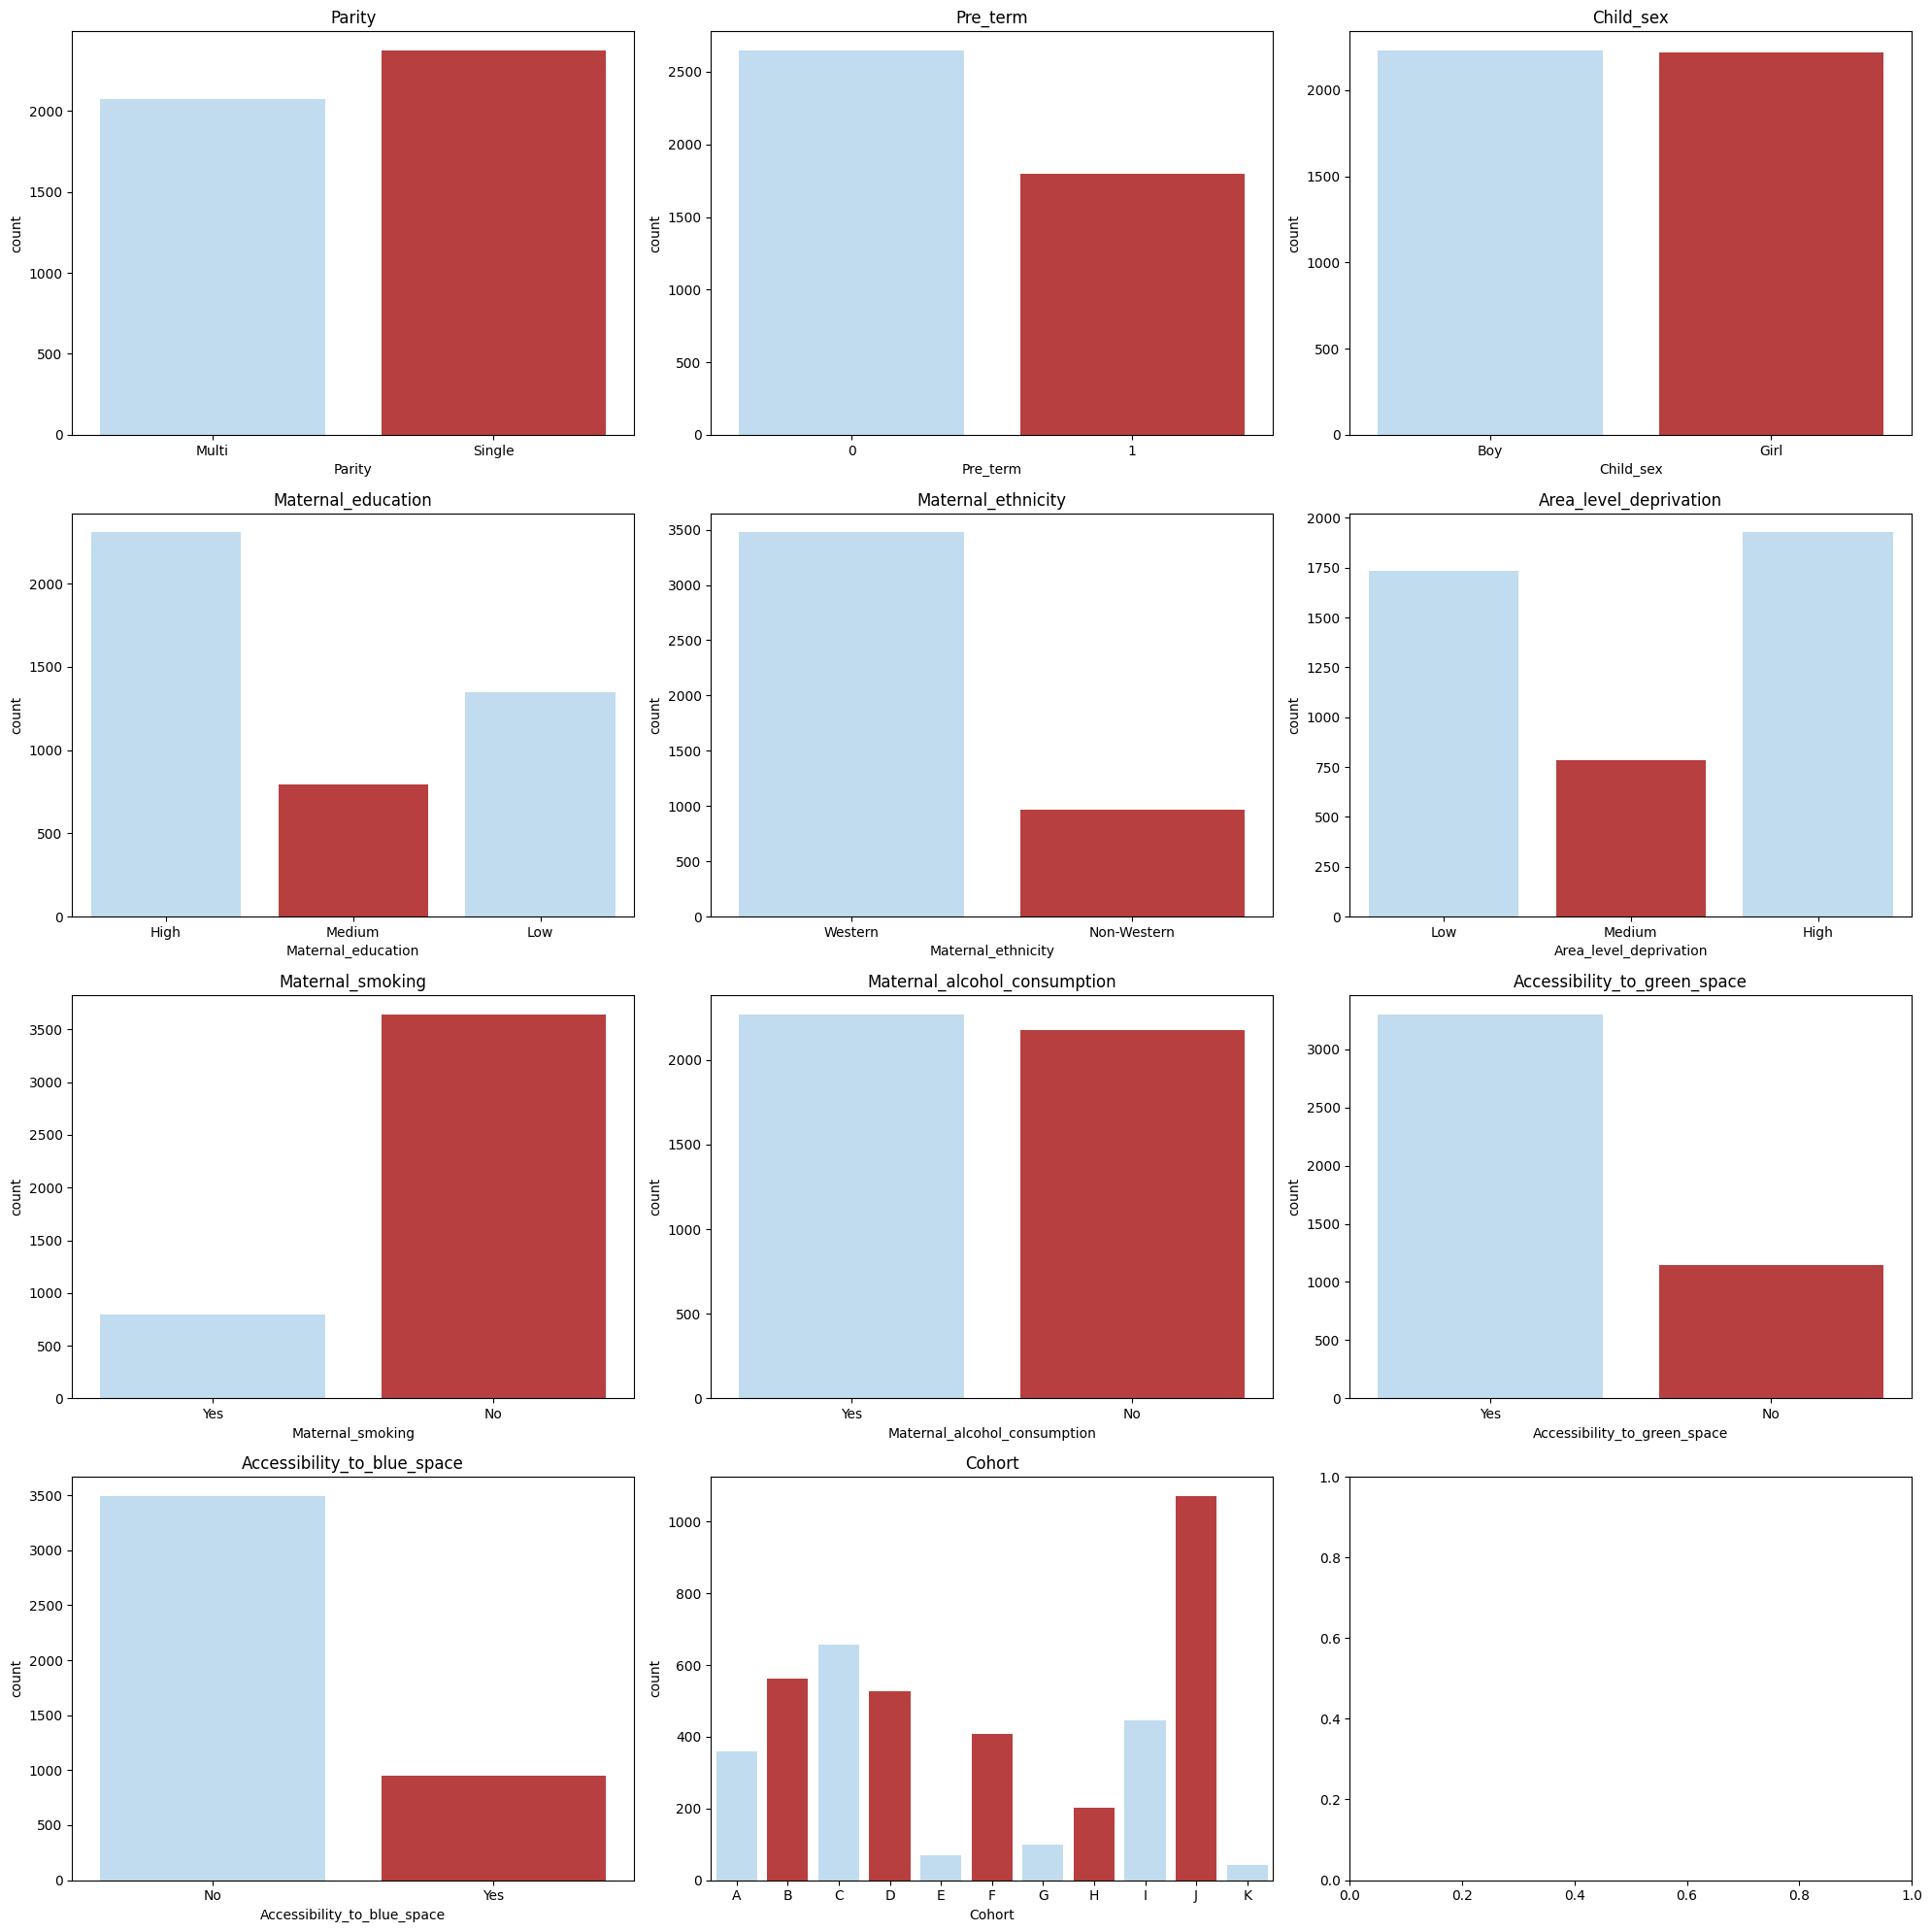

In [20]:
fig, ax = plt.subplots(nrows = 4,ncols = 3,figsize = (20,20))

ax = ax.flatten()
for i in range(len(cat_vars)):
    sns.countplot(data=df, x=cat_vars[i], palette=colors, hue=cat_vars[i], legend=False, ax=ax[i])
    title = cat_vars[i]
    ax[i].set_title(title)
plt.tight_layout() #avoid overlap among subplots
plt.show()

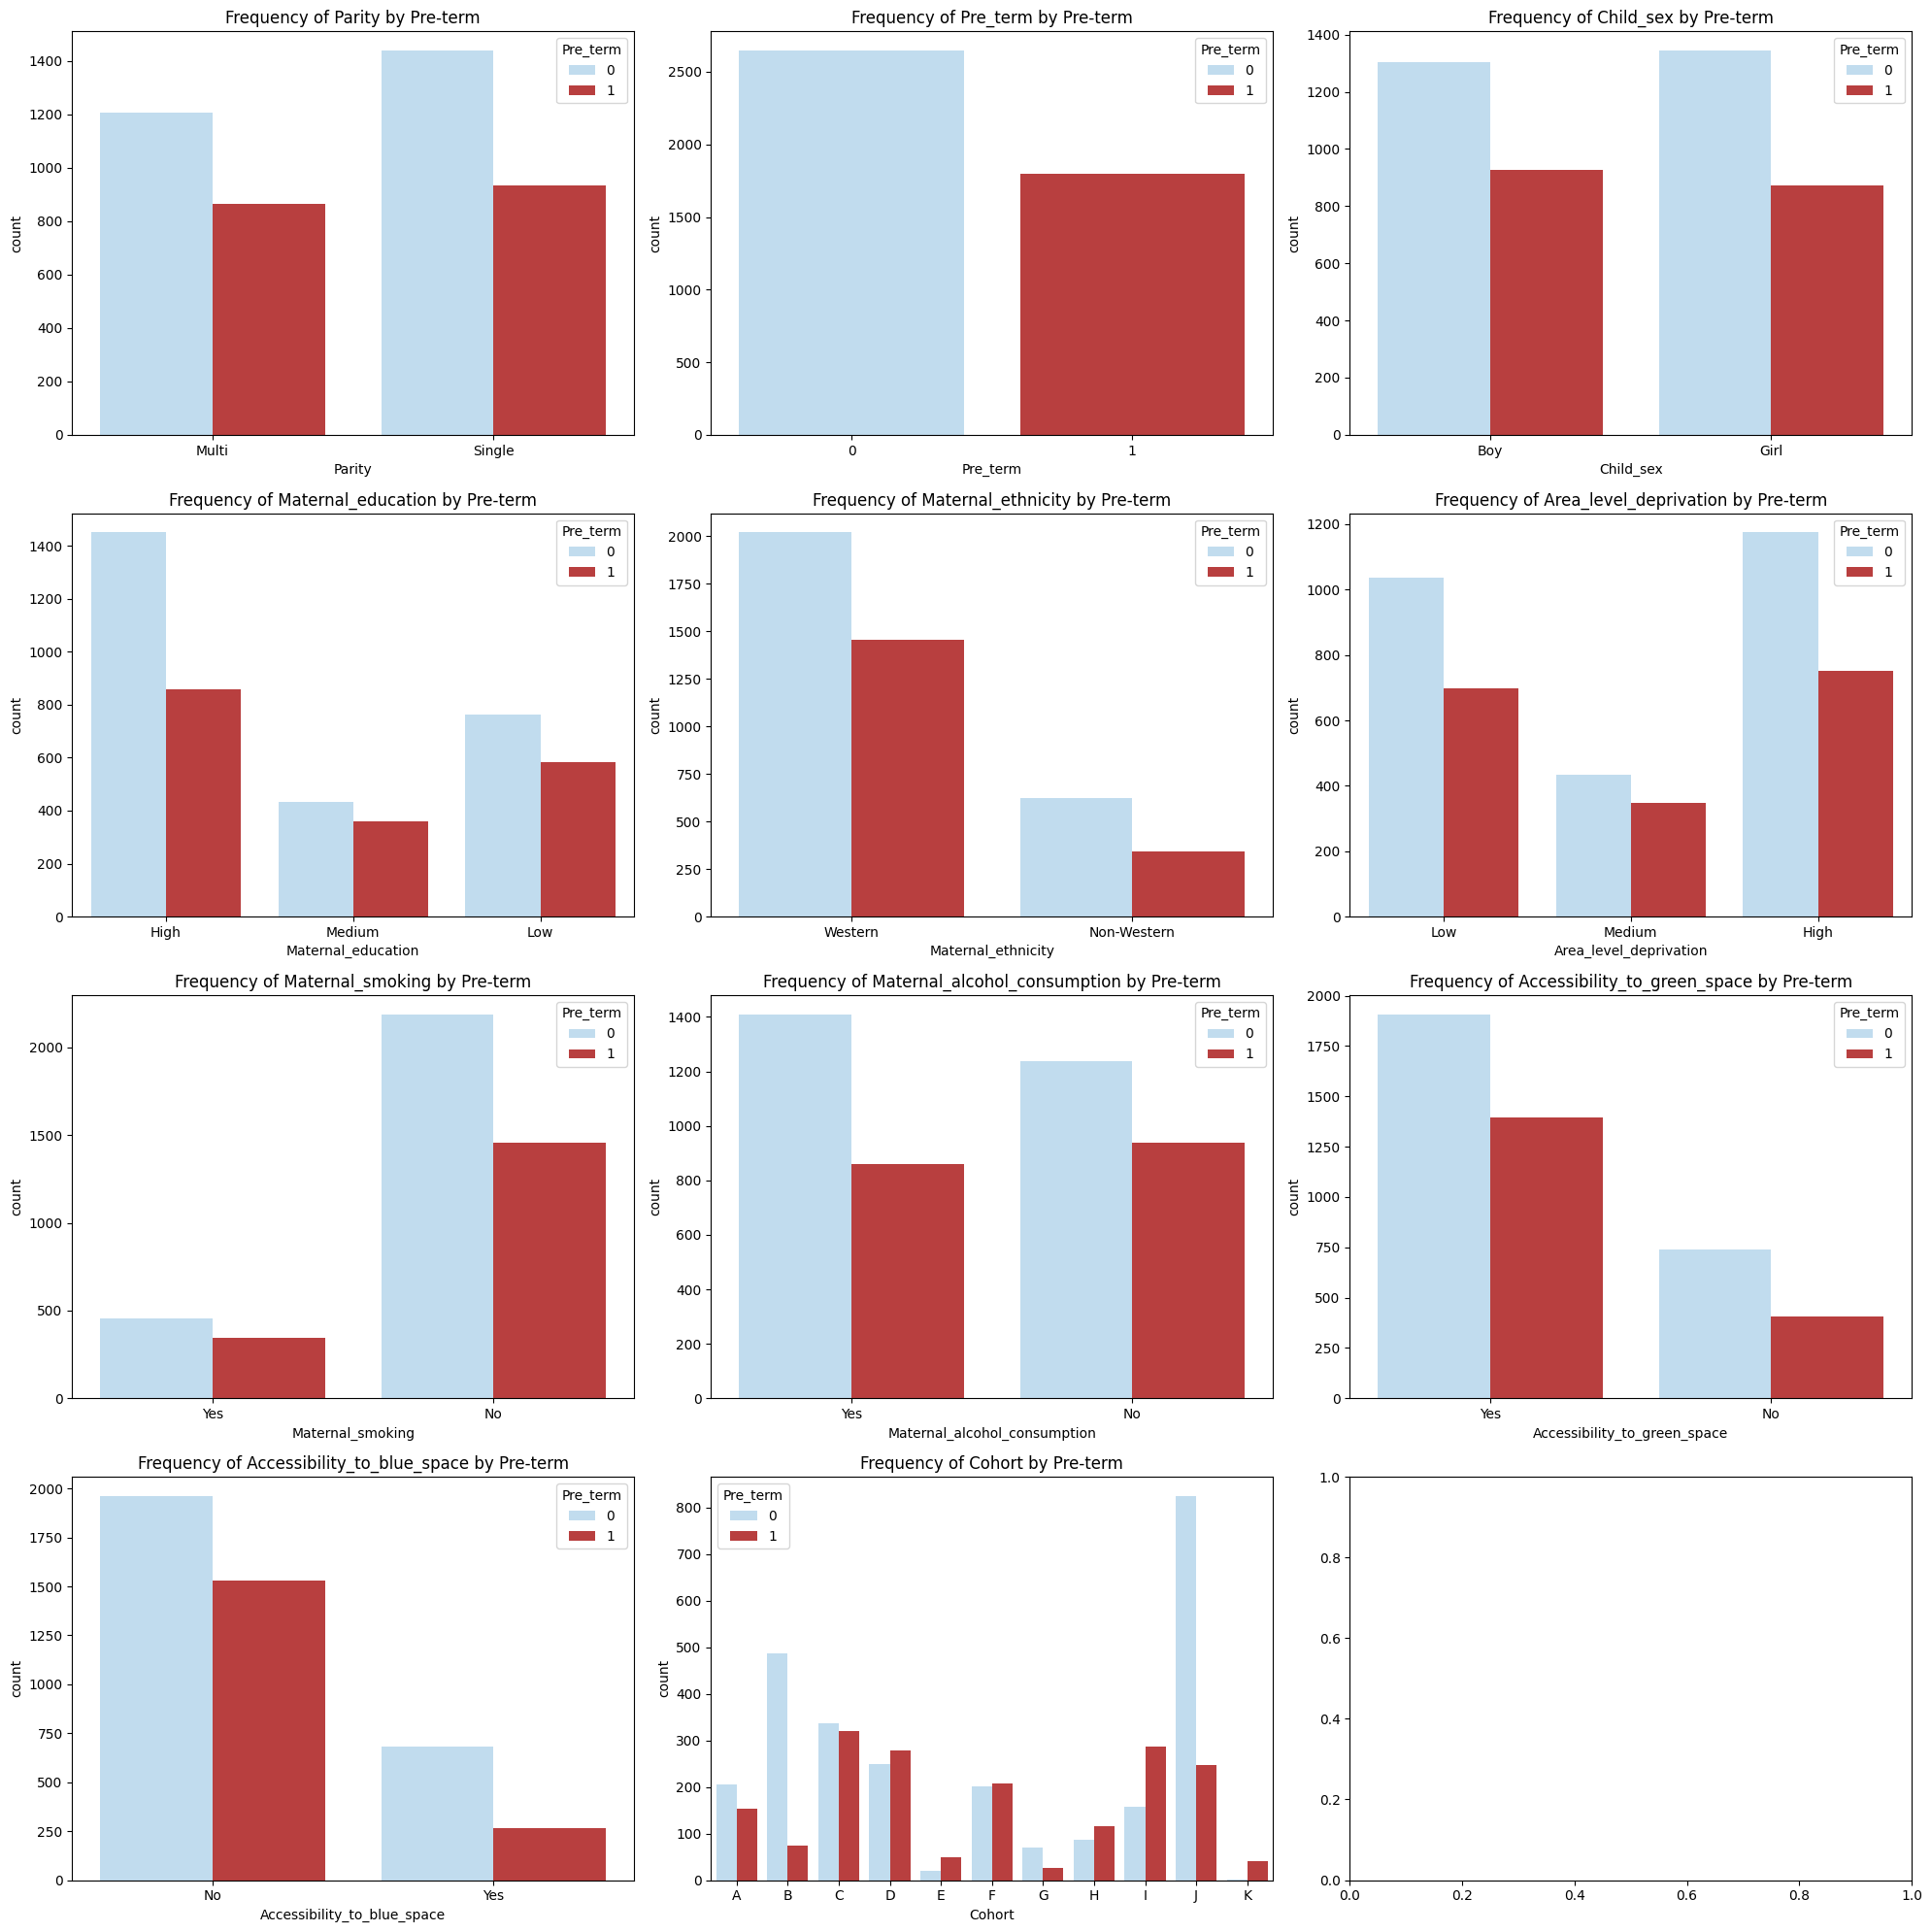

In [21]:
#Barplot frequency of Pre-term in categorical variables

fig, ax = plt.subplots(nrows = 4,ncols = 3,figsize = (20,20))

ax = ax.flatten()
for i in range(len(cat_vars)):
    sns.countplot(data=df, x=cat_vars[i], palette=colors, hue='Pre_term', ax=ax[i])
    title = "Frequency of " + cat_vars[i] + " by Pre-term"
    ax[i].set_title(title)
plt.tight_layout() #avoid overlap among subplots
plt.show()



## Numerical variables

### Main statistics

Describe method computes mean, standard deviation, min, max and quantiles

In [22]:
df[num_vars].describe()

,Maternal_age,NDVI_100m,NDVI_300m,NDVI_500m,Residential_distance_to_green_space,Residential_distance_to_blue_space,NO2,PM2.5,Birth_weight_modelled
count,4445.00,4445.00,4445.00,4445.00,4445.00,4445.00,4445.00,4445.00,4445.00
mean,29.68,0.42,0.43,0.44,220.60,1096.83,26.00,14.96,2964.99
std,4.82,0.14,0.13,0.13,149.49,855.77,9.88,4.65,872.96
min,11.34,-0.14,-0.09,-0.09,0.04,0.22,0.01,4.22,800.00
25%,26.66,0.32,0.35,0.37,104.86,408.14,19.36,11.38,2367.79
50%,29.86,0.41,0.43,0.44,194.09,943.98,25.29,13.93,3050.16
75%,32.92,0.51,0.51,0.53,307.01,1539.52,31.80,18.09,3605.95
max,46.23,0.92,0.89,0.90,1041.46,5443.26,75.90,32.92,4499.86


### Histograms

Histograms with kernel density estimation

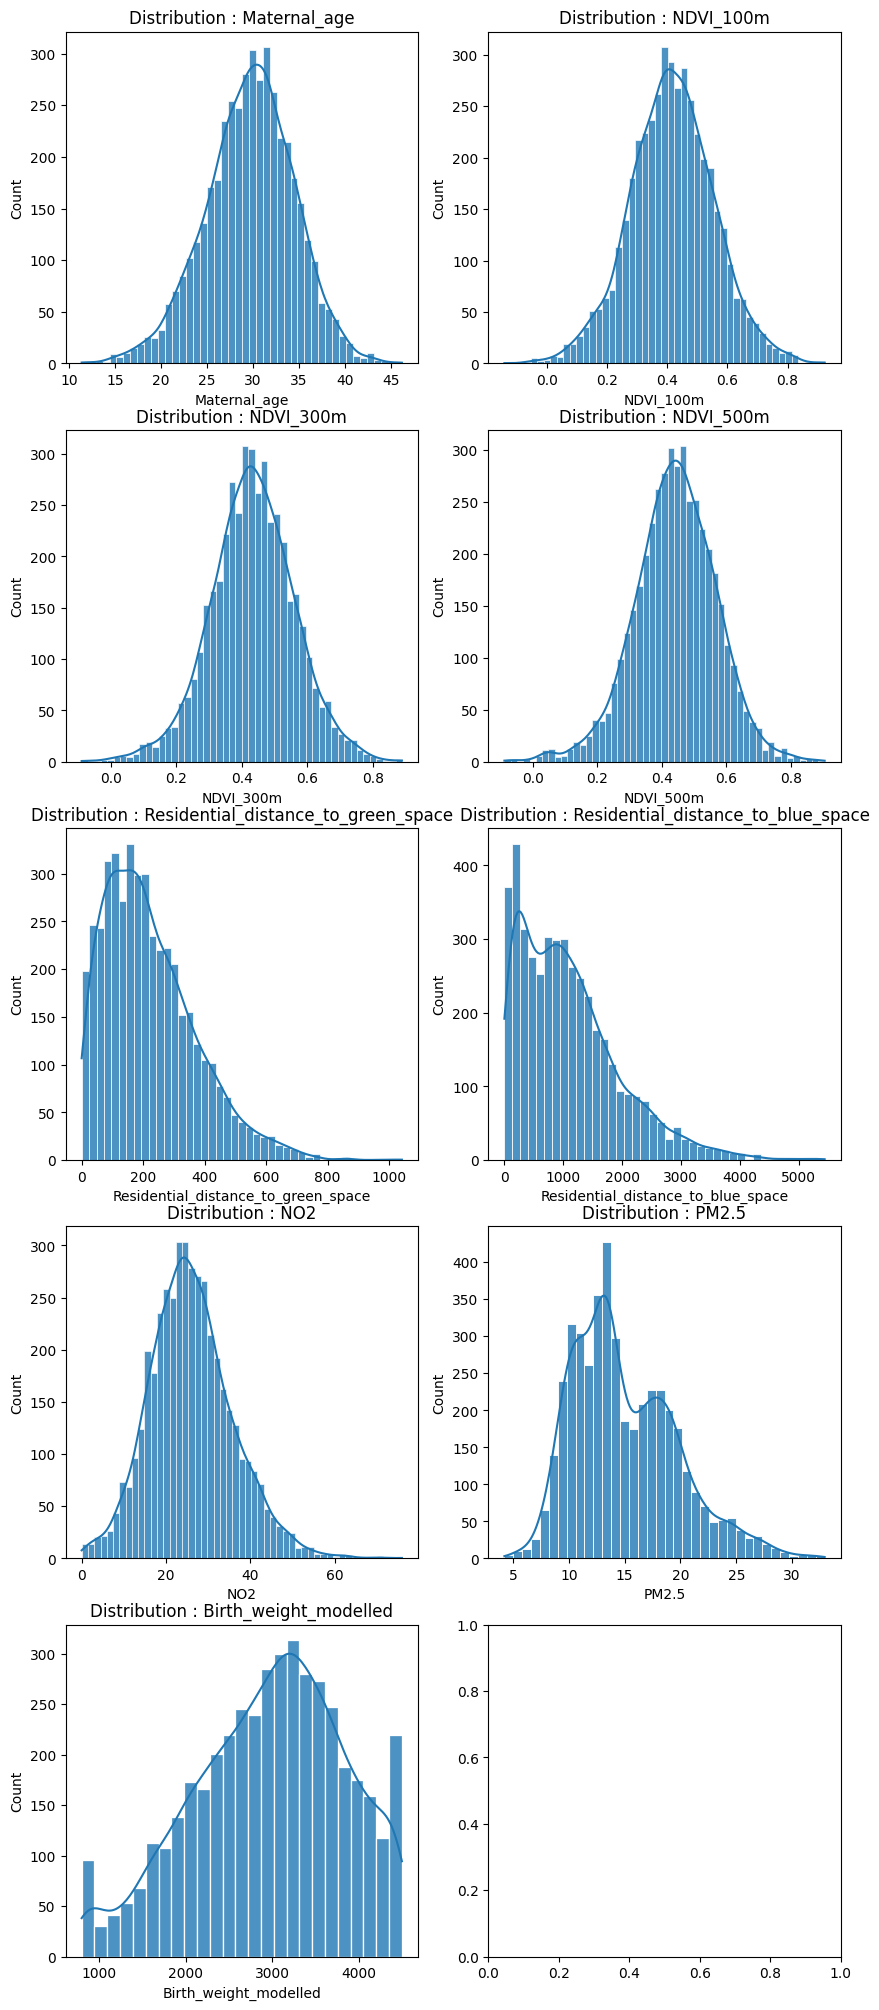

In [23]:
nrows = 5
ncols = 2

fig, ax = plt.subplots(nrows=nrows, ncols=ncols,figsize = (10,25))
for i in range(len(num_vars)):
    plt.subplot(nrows, ncols, i+1)
    sns.histplot(
      data=df, x=num_vars[i], kde=True,
      alpha=.8, edgecolor=(1, 1, 1)
    )
    title = 'Distribution : ' + num_vars[i]
    plt.title(title)
plt.show()

Histogram grouped by a categorical variable

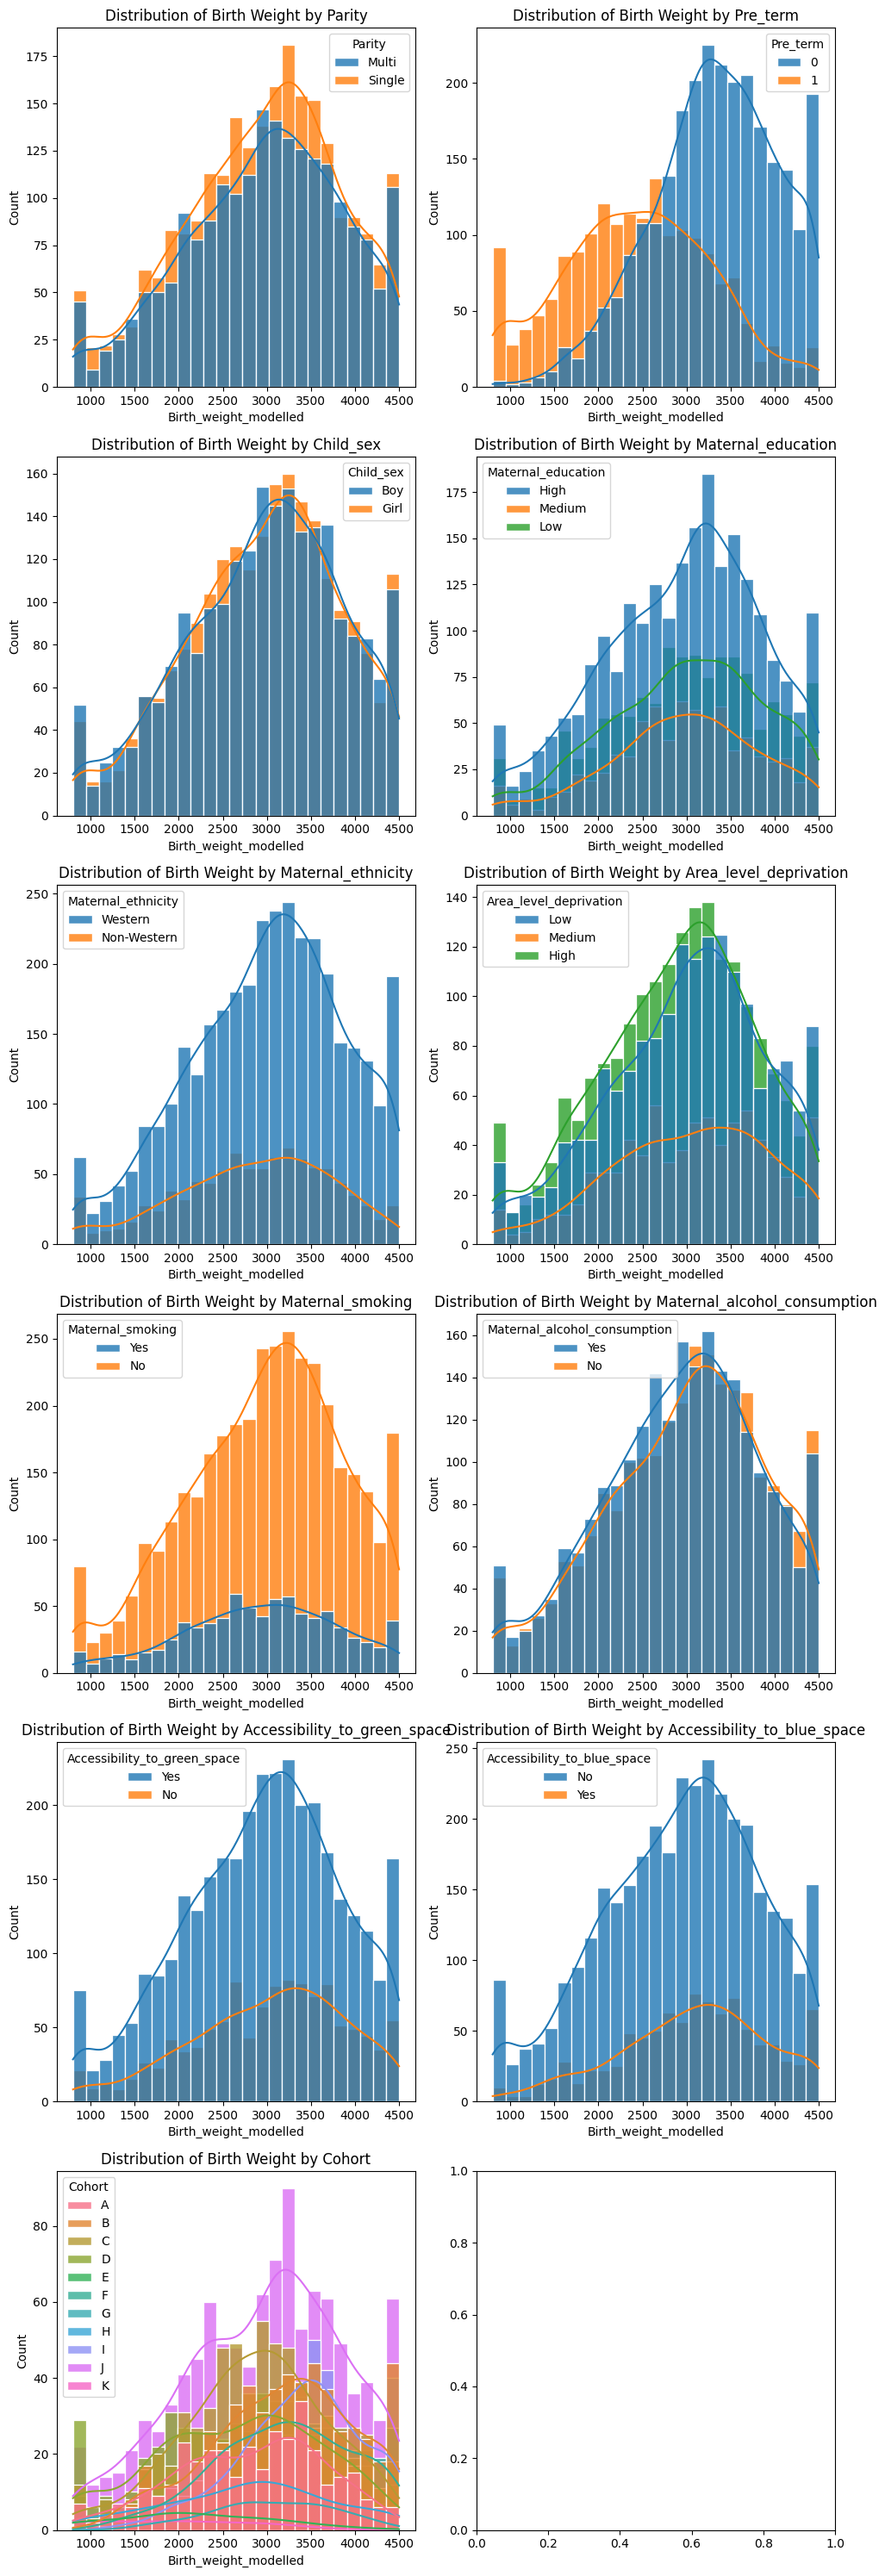

In [24]:
nrows = 6
ncols = 2

fig, ax = plt.subplots(nrows=nrows, ncols=ncols,figsize = (10,30))

for i in cat_vars:
    plt.subplot(nrows, ncols, cat_vars.index(i) + 1)
    sns.histplot(
        data=df, x='Birth_weight_modelled', kde=True,
        hue=i,
        alpha=.8, edgecolor=(1, 1, 1)
    )
    title = 'Distribution of Birth Weight by ' + i
    plt.title(title)
plt.tight_layout()
plt.show()

### Kurtosis and skeweness


In [25]:
results = []

for n in num_vars:
    k = kurtosis(df[n])
    s = skew(df[n])
    results.append({'variable': n, 'kurtosis': k, 'skewness': s})

ks_df = pd.DataFrame(results)

ks_df

,variable,kurtosis,skewness
0,Maternal_age,0.20,-0.22
1,NDVI_100m,0.28,-0.02
2,NDVI_300m,0.50,-0.10
3,NDVI_500m,0.73,-0.21
4,Residential_distance_to_green_space,0.89,0.94
5,Residential_distance_to_blue_space,1.57,1.15
6,NO2,0.62,0.42
7,PM2.5,0.25,0.72
8,Birth_weight_modelled,-0.46,-0.35


### Boxplots

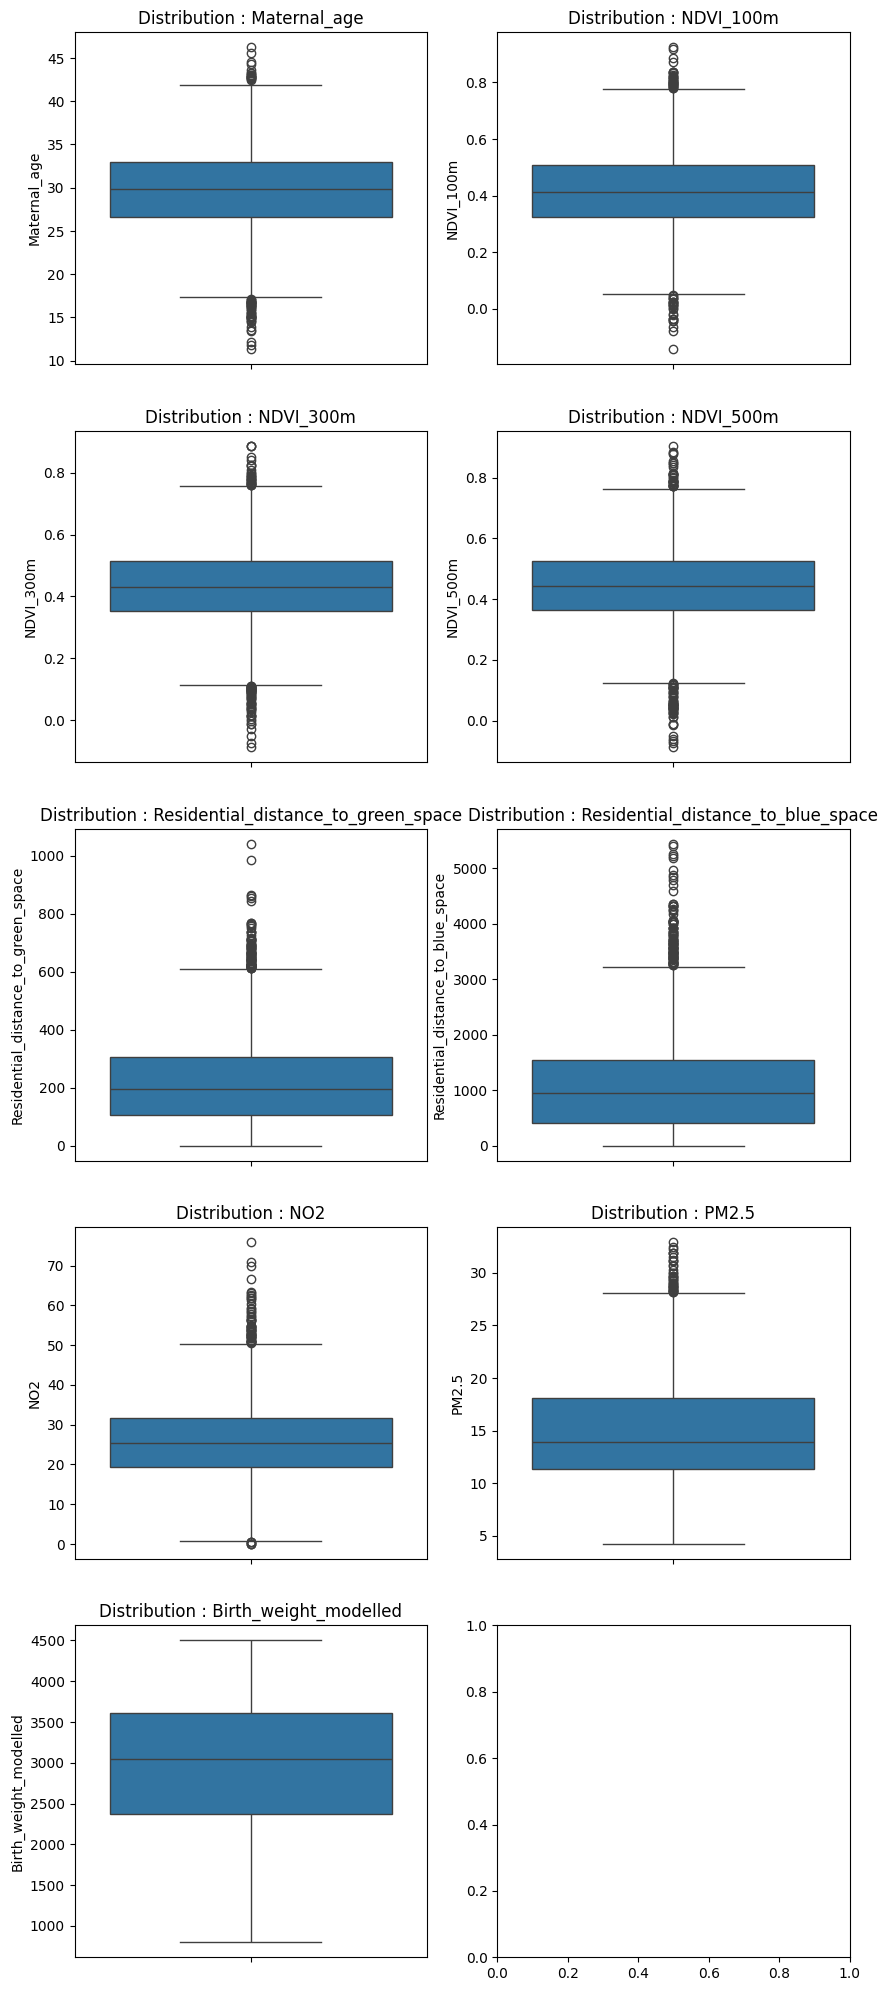

In [26]:
fig, ax = plt.subplots(nrows = 5,ncols = 2,figsize = (10,25))
for i in range(len(num_vars)):
    plt.subplot(5,2,i+1)
    sns.boxplot(data=df, y=num_vars[i])
    title = 'Distribution : ' + num_vars[i]
    plt.title(title)
plt.show()

### Covariance Matrix

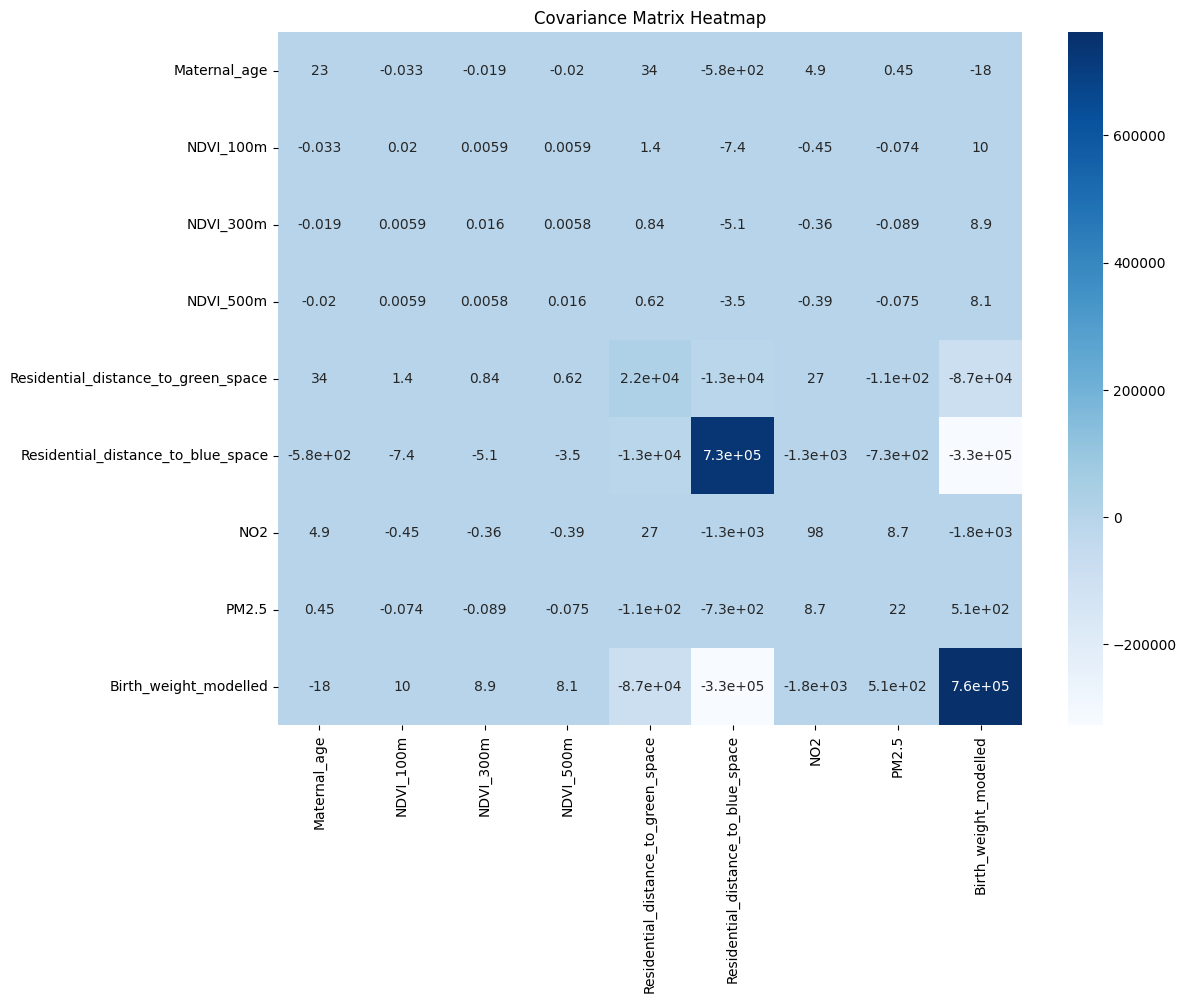

In [27]:
cov_matrix = df[num_vars].cov()

plt.figure(figsize=(12, 9))
sns.heatmap(cov_matrix, annot=True, cmap='Blues')

plt.title('Covariance Matrix Heatmap')
plt.show()

### Correlation matrix

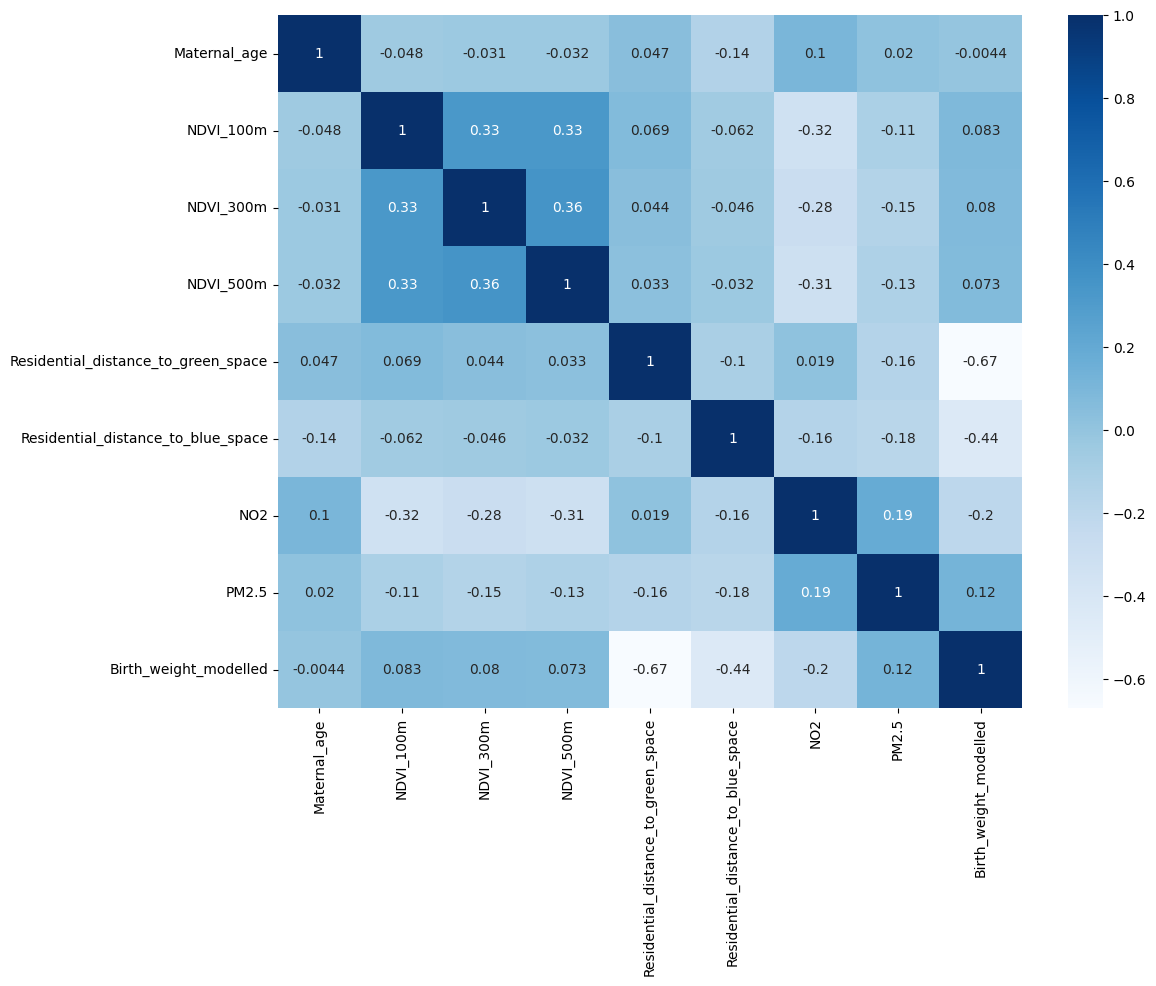

In [28]:
corrmat = df[num_vars].corr()
plt.figure(figsize=(12,9))
sns.heatmap(corrmat, cmap="Blues",annot=True);

### Scatterplot

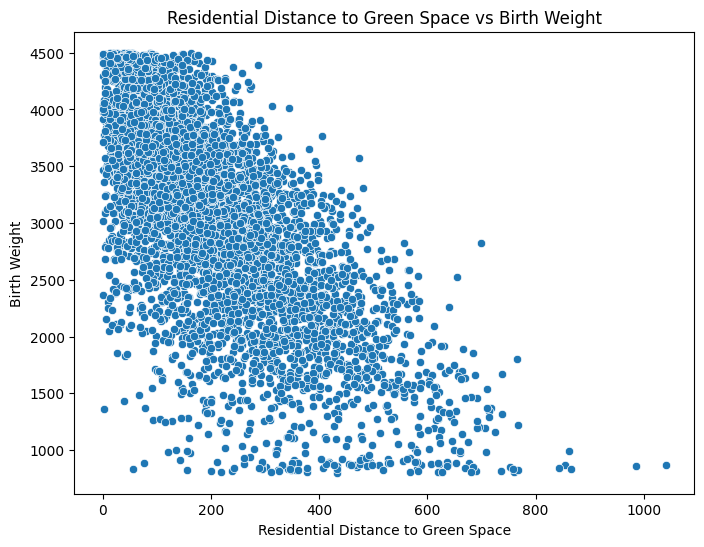

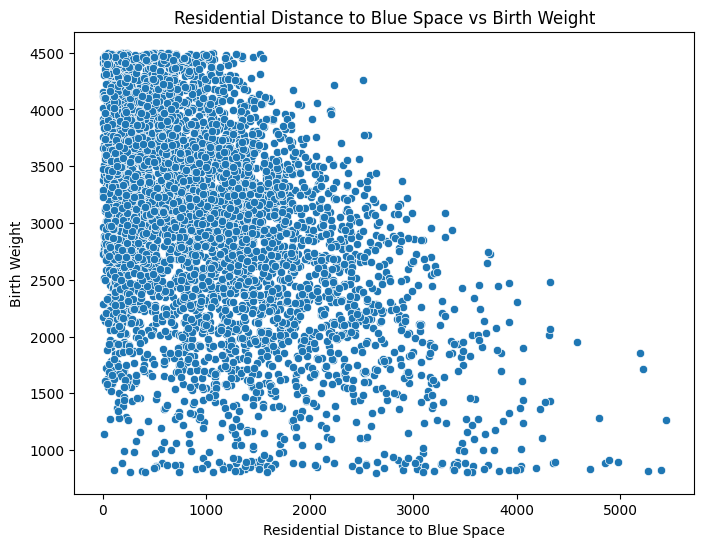

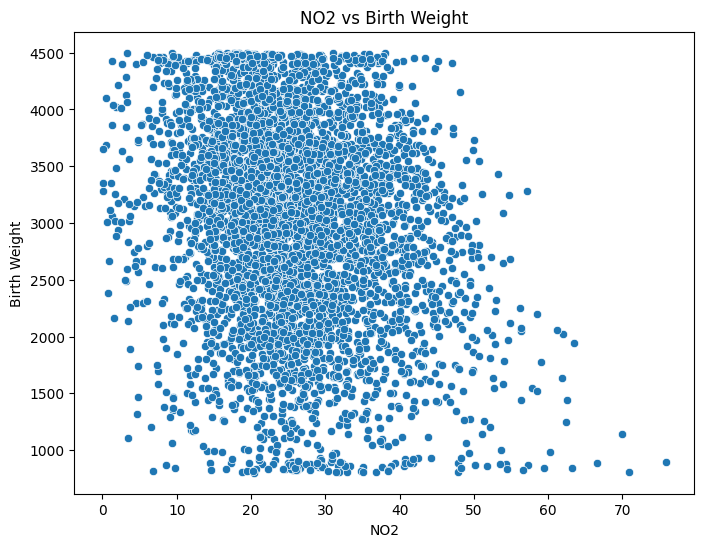

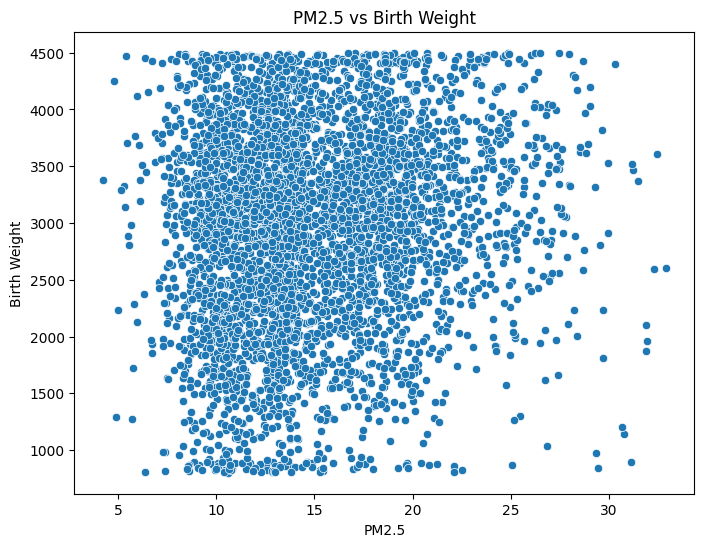

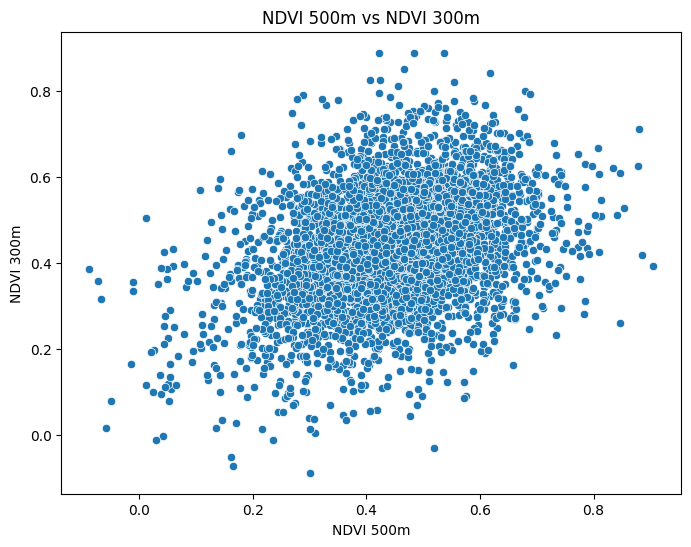

In [29]:
# Scatterplot between distance to green spaces and birth weight
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Residential_distance_to_green_space', y='Birth_weight_modelled', data=df)
plt.title('Residential Distance to Green Space vs Birth Weight')
plt.xlabel('Residential Distance to Green Space')
plt.ylabel('Birth Weight')
plt.show()

# Scatterplot between distance to blue spaces and birth weight
plt.figure(figsize=(8, 6))
sns.scatterplot(x='Residential_distance_to_blue_space', y='Birth_weight_modelled', data=df)
plt.title('Residential Distance to Blue Space vs Birth Weight')
plt.xlabel('Residential Distance to Blue Space')
plt.ylabel('Birth Weight')
plt.show()

# Scatterplot between NO2 and birth weight
plt.figure(figsize=(8, 6))
sns.scatterplot(x='NO2', y='Birth_weight_modelled', data=df)
plt.title('NO2 vs Birth Weight')
plt.xlabel('NO2')
plt.ylabel('Birth Weight')
plt.show()

# Scatterplot between PM2.5 and birth weight
plt.figure(figsize=(8, 6))
sns.scatterplot(x='PM2.5', y='Birth_weight_modelled', data=df)
plt.title('PM2.5 vs Birth Weight')
plt.xlabel('PM2.5')
plt.ylabel('Birth Weight')
plt.show()

# Scatterplot between NDVI_500m and NDVI_300
plt.figure(figsize=(8, 6))
sns.scatterplot(x='NDVI_500m', y='NDVI_300m', data=df)
plt.title('NDVI 500m vs NDVI 300m')
plt.xlabel('NDVI 500m')
plt.ylabel('NDVI 300m')
plt.show()

<Axes: xlabel='Maternal_age', ylabel='Birth_weight_modelled'>

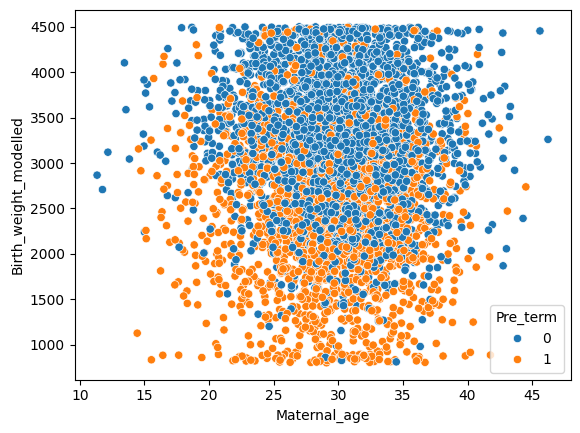

In [30]:
sns.scatterplot(data=df, x='Maternal_age', y='Birth_weight_modelled', hue='Pre_term')

# **Statistical Tests**

## Shapiro Test

In [31]:
shapiro_results = []

for n in num_vars:
  _, p= shapiro(df[n])
  shapiro_results.append({'var': n, 'p': p})
  if p > 0.05:
    print(f"The variable {n} is normally distributed")
  else:
    print(f"The variable {n} is not normally distributed")

shapiro_results = pd.DataFrame(shapiro_results)
shapiro_results



The variable Maternal_age is not normally distributed
The variable NDVI_100m is not normally distributed
The variable NDVI_300m is not normally distributed
The variable NDVI_500m is not normally distributed
The variable Residential_distance_to_green_space is not normally distributed
The variable Residential_distance_to_blue_space is not normally distributed
The variable NO2 is not normally distributed
The variable PM2.5 is not normally distributed
The variable Birth_weight_modelled is not normally distributed


,var,p
0,Maternal_age,0.00
1,NDVI_100m,0.00
2,NDVI_300m,0.00
3,NDVI_500m,0.00
4,Residential_distance_to_green_space,0.00
5,Residential_distance_to_blue_space,0.00
6,NO2,0.00
7,PM2.5,0.00
8,Birth_weight_modelled,0.00


## QQ plot

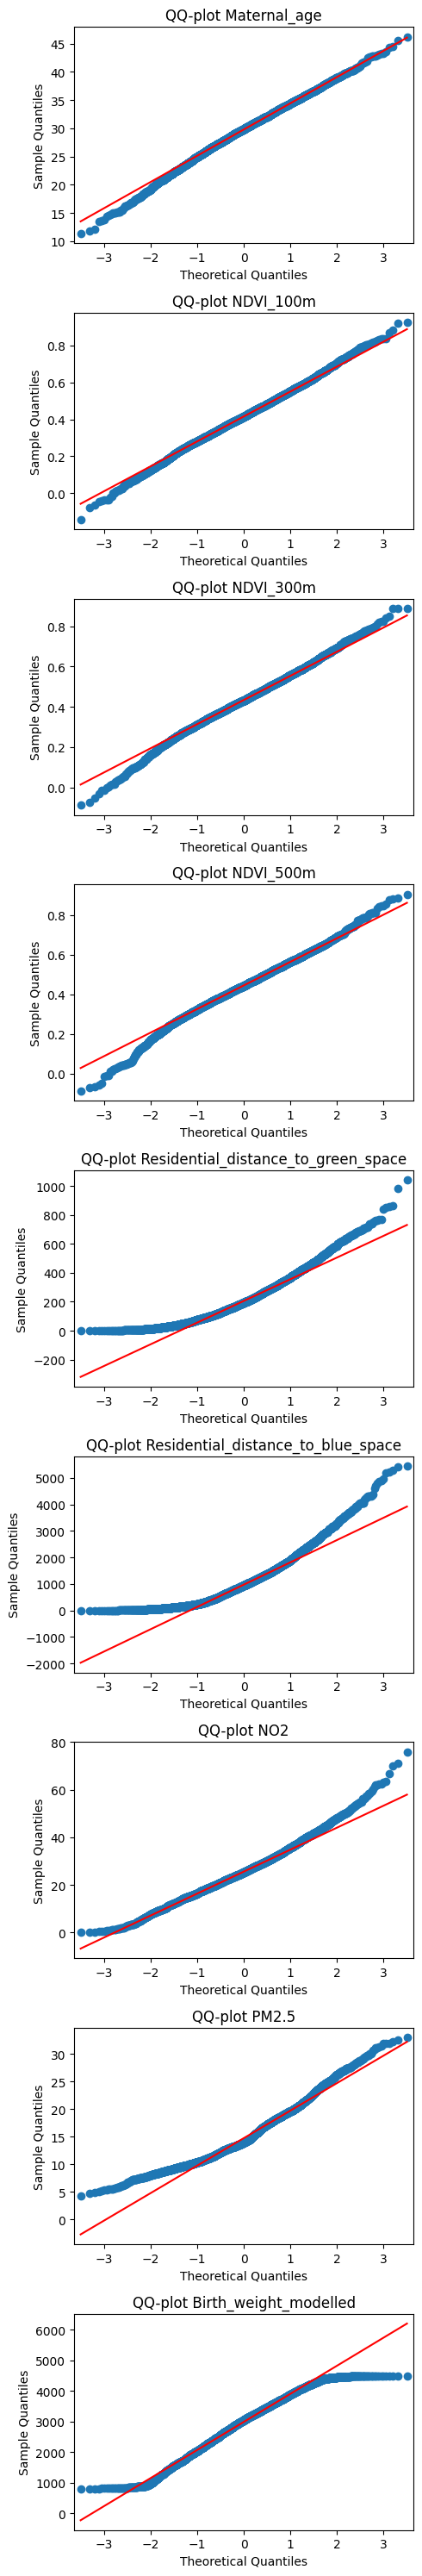

In [32]:
fig, axs = plt.subplots(len(num_vars), figsize=(5,30))

for (i,v) in enumerate(num_vars):
  sm.qqplot(df[v], line='q', ax=axs[i])
  axs[i].set_title('QQ-plot ' + v)
plt.tight_layout()

## T-test

In [33]:
#Perform Levene's Test and T test to compare the means of all the Numerical Variables Between Preterm and Non-Preterm Groups

preterm = df[df['Pre_term'] == 1]
no_preterm = df[df['Pre_term'] == 0]

for var in num_vars:

    stat, p_value_levene = levene(preterm[var], no_preterm[var])
    print(f"\nVariable: {var}")
    print(f"Levene's test p-value for equal variances: {p_value_levene}")

    t_stat, p_value_ttest = ttest_ind(preterm[var], no_preterm[var], equal_var=(p_value_levene >= 0.05), alternative='two-sided')
    print(f"T-test p-value: {p_value_ttest}")

    cm = sms.CompareMeans(sms.DescrStatsW(preterm[var]), sms.DescrStatsW(no_preterm[var]))
    conf_int = cm.tconfint_diff(usevar='unequal')
    print(f"95% Confidence interval for the difference in means: {conf_int}")
    conf_int_width = conf_int[1] - conf_int[0]
    print(f"Width of the confidence interval: {conf_int_width}")



Variable: Maternal_age
Levene's test p-value for equal variances: 0.012809458762549233
T-test p-value: 8.297746797891274e-05
95% Confidence interval for the difference in means: (-0.8746526236461196, -0.2934053503012788)
Width of the confidence interval: 0.5812472733448408

Variable: NDVI_100m
Levene's test p-value for equal variances: 0.8845502839426767
T-test p-value: 1.997327795286689e-05
95% Confidence interval for the difference in means: (-0.02658347850294513, -0.0098269473355394)
Width of the confidence interval: 0.016756531167405733

Variable: NDVI_300m
Levene's test p-value for equal variances: 0.001558716092305308
T-test p-value: 4.783129048326391e-06
95% Confidence interval for the difference in means: (-0.02526090825002286, -0.010117583405382994)
Width of the confidence interval: 0.015143324844639865

Variable: NDVI_500m
Levene's test p-value for equal variances: 0.3571157872657932
T-test p-value: 0.0004752027144801171
95% Confidence interval for the difference in means: (

In [34]:
# Perform Levene's test to check for equality of variances in birth weight between the two groups (Multi/Sigle Parity)
multi = df[df['Parity'] == "Multi"]
single = df[df['Parity'] == "Single"]
stat, p_value = levene(multi['Birth_weight_modelled'], single['Birth_weight_modelled'])
print(f"p-value: {p_value}")

# Perform a T-test to compare the means of birth weight between the two groups
ttest_ind(multi['Birth_weight_modelled'], single['Birth_weight_modelled'], equal_var=True, alternative='two-sided')

p-value: 0.8958490406744772


TtestResult(statistic=0.7514631560597567, pvalue=0.45241376781250153, df=4443.0)

In [35]:
# Perform Levene's test to check for equality of variances in birth weight between the two groups (Child Sex)
boy = df[df['Child_sex'] == "Boy"]
girl = df[df['Child_sex'] == "Girl"]
stat, p_value = levene(boy['Birth_weight_modelled'], girl['Birth_weight_modelled'])
print(f"p-value: {p_value}")

# Perform a T-test to compare the means of birth weight between the two groups
ttest_ind(boy['Birth_weight_modelled'], girl['Birth_weight_modelled'], equal_var=True, alternative='two-sided')

p-value: 0.39541155041133336


TtestResult(statistic=-0.3893888614256763, pvalue=0.697007172509954, df=4443.0)

In [36]:
#Perform Levene's test to check for equality of variances in birth weight between Western and Non-Western
western = df[df['Maternal_ethnicity'] == "Western"]
no_western = df[df['Maternal_ethnicity'] == "Non-Western"]
stat, p_value = levene(western['Birth_weight_modelled'], no_western['Birth_weight_modelled'])
print(f"p-value: {p_value}")

# Perform a T-test to compare the means of birth weight between Western and Non-Western
print(ttest_ind(western['Birth_weight_modelled'], no_western['Birth_weight_modelled'], equal_var=True, alternative='two-sided'))

# CompareMeans to calculate confidence intervals for the difference in means
cm = sms.CompareMeans(sms.DescrStatsW(western['Birth_weight_modelled']), sms.DescrStatsW(no_western['Birth_weight_modelled']))
print(cm.tconfint_diff(usevar='unequal'))
res_2 = cm.tconfint_diff(usevar='unequal')
print('Width without equal variance assumption:', res_2[1] - res_2[0])

p-value: 0.6046730827102361
TtestResult(statistic=4.396977515616403, pvalue=1.1233418344112535e-05, df=4443.0)
(76.78071321316361, 201.5220389900453)
Width without equal variance assumption: 124.7413257768817


In [37]:
#Perform Levene's test to check for equality of variances in birth weight between smokers and non-smokers
smoke = df[df['Maternal_smoking'] == "Yes"] # Fumatori
no_smoke = df[df['Maternal_smoking'] == "No"]  # Non fumatori
stat, p_value = levene(smoke['Birth_weight_modelled'], no_smoke['Birth_weight_modelled'])
print(f"p-value: {p_value}")

# Perform a T-test to compare the means of birth weight between smokers and non-smokers
ttest_ind(smoke['Birth_weight_modelled'], no_smoke['Birth_weight_modelled'], equal_var=True, alternative='two-sided')

p-value: 0.91326236394913


TtestResult(statistic=-1.7002948108697855, pvalue=0.08914547226736116, df=4443.0)

In [38]:
# Perform Levene's test to check for equality of variances in birth weight between the two groups (alchol and no_alchol)
alchol = df[df['Maternal_alcohol_consumption'] == "Yes"]
no_alchol = df[df['Maternal_alcohol_consumption'] == "No"]
stat, p_value = levene(alchol['Birth_weight_modelled'], no_alchol['Birth_weight_modelled'])
print(f"p-value: {p_value}")

# Perform a T-test to compare the means of birth weight between the two groups
print(ttest_ind(alchol['Birth_weight_modelled'], no_alchol['Birth_weight_modelled'], equal_var=True, alternative='two-sided'))

# CompareMeans to calculate confidence intervals for the difference in means
cm = sms.CompareMeans(sms.DescrStatsW(alchol['Birth_weight_modelled']), sms.DescrStatsW(no_alchol['Birth_weight_modelled']))
print(cm.tconfint_diff(usevar='unequal'))
res = cm.tconfint_diff(usevar='pooled')
print('Width with equal variance assumption:', res[1] - res[0])

p-value: 0.5211023489104458
TtestResult(statistic=-2.2400547908878683, pvalue=0.02513661649426847, df=4443.0)
(-109.99079627680686, -7.304030531484095)
Width with equal variance assumption: 102.65654286145474


In [39]:
# Perform Levene's test to check for equality of variances in birth weight between the two groups (Accessibility to green space Yes/No)
green = df[df['Accessibility_to_green_space'] == "Yes"]
no_green = df[df['Accessibility_to_green_space'] == "No"]
stat, p_value = levene(green['Birth_weight_modelled'], no_green['Birth_weight_modelled'])
print(f"p-value: {p_value}")

# Perform a T-test to compare the means of birth weight between the two groups
print(ttest_ind(green['Birth_weight_modelled'], no_green['Birth_weight_modelled'], equal_var=True, alternative='two-sided'))

# CompareMeans to calculate confidence intervals for the difference in means
cm = sms.CompareMeans(sms.DescrStatsW(green['Birth_weight_modelled']), sms.DescrStatsW(no_green['Birth_weight_modelled']))
print(cm.tconfint_diff(usevar='unequal'))
res = cm.tconfint_diff(usevar='pooled')
print('Width with equal variance assumption:', res[1] - res[0])

p-value: 0.6372322616613965
TtestResult(statistic=-2.4679437040641545, pvalue=0.013626568194667359, df=4443.0)
(-132.28674160015564, -15.499499841729438)
Width with equal variance assumption: 117.39920950211366


In [40]:
# Perform Levene's test to check for equality of variances in birth weight between the two groups (Accessibility to blue space Yes/No)
blue = df[df['Accessibility_to_blue_space'] == "Yes"]
no_blue = df[df['Accessibility_to_blue_space'] == "No"]
stat, p_value = levene(blue['Birth_weight_modelled'], no_blue['Birth_weight_modelled'])
print(f"p-value: {p_value}")

# Perform a T-test to compare the means of birth weight between the two groups
print(ttest_ind(blue['Birth_weight_modelled'], no_blue['Birth_weight_modelled'], equal_var=False, alternative='two-sided'))

# CompareMeans to calculate confidence intervals for the difference in means
cm = sms.CompareMeans(sms.DescrStatsW(blue['Birth_weight_modelled']), sms.DescrStatsW(no_blue['Birth_weight_modelled']))
print(cm.tconfint_diff(usevar='unequal'))
res = cm.tconfint_diff(usevar='pooled')
print('Width with equal variance assumption:', res[1] - res[0])

p-value: 0.005168135303088424
TtestResult(statistic=4.296838245544281, pvalue=1.8382662767469894e-05, df=1579.1979077338638)
(72.0060853382958, 192.9612460765946)
Width with equal variance assumption: 124.96248586765786


In [41]:
#Perform Levene's test to check for equality of variances in birth weight between Preterm and Non-Preterm
preterm = df[df['Pre_term'] == 1]
no_preterm = df[df['Pre_term'] == 0]
stat, p_value = levene(preterm['Birth_weight_modelled'], no_preterm['Birth_weight_modelled'])
print(f"p-value: {p_value}")

# Perform a T-test to compare the means of birth weight between Preterm and Non-Preterm groups
print (ttest_ind(preterm['Birth_weight_modelled'], no_preterm['Birth_weight_modelled'], equal_var=False, alternative='two-sided'))

# CompareMeans to calculate confidence intervals for the difference in means
cm = sms.CompareMeans(sms.DescrStatsW(preterm['Birth_weight_modelled']), sms.DescrStatsW(no_preterm['Birth_weight_modelled']))
print(cm.tconfint_diff(usevar='unequal'))
res_2 = cm.tconfint_diff(usevar='unequal')
print('Width without equal variance assumption:', res_2[1] - res_2[0])

p-value: 3.2202953213887185e-17
TtestResult(statistic=-36.15499683412793, pvalue=1.4808732495170893e-242, df=3406.1618400739394)
(-916.6096442118919, -822.3092639272559)
Width without equal variance assumption: 94.30038028463605


## ANOVA

In [42]:
#ANOVA Test for Differences in Birth Weight Across Maternal Education Levels
var = 'Birth_weight_modelled'
grouped_education = []
for group_name in df['Maternal_education'].unique():
    group = df[df['Maternal_education'] == group_name][var]
    grouped_education.append(group)

# Shapiro-Wilk test for normality
for i, group in enumerate(grouped_education):
    stat, p_value = shapiro(group)
    print(f"Normality test for Maternal_education group {i}: p-value = {p_value}")
    if p_value > 0.05:
        print(f"The group {i} is normally distributed")
    else:
        print(f"The group {i} is not normally distributed")

# Test for equal variances across Maternal_Education groups
stat, p_value = levene(*grouped_education)
print(f"Levene's test for equal variances across Maternal_education groups: p-value = {p_value}")
if p_value > 0.05:
    print("The variances are equal across groups")
else:
    print("The variances are not equal across groups")

#Perform ANOVA test
formula = 'Birth_weight_modelled ~ C(Maternal_education)'
model = smf.ols(formula, data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print("ANOVA results for Maternal_education:")
print(anova_table)

#Kruskal-Wallis test
kruskal_result = kruskal(*grouped_education)
print(f"Kruskal-Wallis test for Maternal_education groups: p-value = {kruskal_result.pvalue}")

anova_p_value = anova_table.loc['C(Maternal_education)', 'PR(>F)']
if anova_p_value > 0.05:
    print("There are no statistically significant differences in birth weight across the Maternal_education groups.")
else:
    print("There are statistically significant differences in birth weight across the Maternal_education groups.")

Normality test for Maternal_education group 0: p-value = 5.78496376998777e-18
The group 0 is not normally distributed
Normality test for Maternal_education group 1: p-value = 3.440963724816022e-08
The group 1 is not normally distributed
Normality test for Maternal_education group 2: p-value = 1.4106168889605216e-13
The group 2 is not normally distributed
Levene's test for equal variances across Maternal_education groups: p-value = 0.0802773477176948
The variances are equal across groups
ANOVA results for Maternal_education:
                             sum_sq      df    F  PR(>F)
C(Maternal_education)    1818743.87    2.00 1.19    0.30
Residual              3384753286.38 4442.00  NaN     NaN
Kruskal-Wallis test for Maternal_education groups: p-value = 0.37788471999181217
There are no statistically significant differences in birth weight across the Maternal_education groups.


In [43]:
#ANOVA Test for Differences in Birth Weight Across Area_Level_Deprivation groups
grouped_deprivation = []
for group_name in df['Area_level_deprivation'].unique():
    group = df[df['Area_level_deprivation'] == group_name][var]
    grouped_deprivation.append(group)

# Shapiro-Wilk test for normality
for i, group in enumerate(grouped_deprivation):
    stat, p_value = shapiro(group)
    print(f"Normality test for Area_level_deprivation group {i}: p-value = {p_value}")

# Test for equal variances across Area_Level_Deprivation groups
stat, p_value = levene(*grouped_deprivation)
print(f"Levene's test for equal variances across Area_level_deprivation groups: p-value = {p_value}")

#Perform ANOVA test
formula = 'Birth_weight_modelled ~ C(Area_level_deprivation)'
model = smf.ols(formula, data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print("ANOVA results for Area_level_deprivation:")
print(anova_table)

#Perform Kruskal-Wallis test
kruskal_result = kruskal(*grouped_deprivation)
print(f"Kruskal-Wallis test for Area_level_deprivation groups: p-value = {kruskal_result.pvalue}")

anova_p_value = anova_table.loc['C(Area_level_deprivation)', 'PR(>F)']
if anova_p_value > 0.05:
    print("There are no statistically significant differences in birth weight across the Area_level_deprivation groups.")
else:
    print("There are statistically significant differences in birth weight across the Area_level_deprivation groups.")

Normality test for Area_level_deprivation group 0: p-value = 5.150716007566517e-16
Normality test for Area_level_deprivation group 1: p-value = 1.402790791255587e-09
Normality test for Area_level_deprivation group 2: p-value = 7.334969245448907e-15
Levene's test for equal variances across Area_level_deprivation groups: p-value = 0.7080901238685001
ANOVA results for Area_level_deprivation:
                                 sum_sq      df    F  PR(>F)
C(Area_level_deprivation)   11869906.09    2.00 7.81    0.00
Residual                  3374702124.16 4442.00  NaN     NaN
Kruskal-Wallis test for Area_level_deprivation groups: p-value = 0.00037686882339283757
There are statistically significant differences in birth weight across the Area_level_deprivation groups.


In [44]:
#ANOVA Test for Differences in Birth Weight Across Cohort groups
grouped_deprivation = []
for group_name in df['Cohort'].unique():
    group = df[df['Cohort'] == group_name][var]
    grouped_deprivation.append(group)

# Shapiro-Wilk test for normality
for i, group in enumerate(grouped_deprivation):
    stat, p_value = shapiro(group)
    print(f"Normality test for Cohort group {i}: p-value = {p_value}")

#Test for equal variances across Cohort groups
stat, p_value = levene(*grouped_deprivation)
print(f"Levene's test for equal variances across cohort groups: p-value = {p_value}")

#Perform ANOVA test
formula = 'Birth_weight_modelled ~ C(Cohort)'
model = smf.ols(formula, data=df).fit()
anova_table = sm.stats.anova_lm(model, typ=2)
print("ANOVA results for Cohort:")
print(anova_table)

#Perform Kruskal-Wallis test
kruskal_result = kruskal(*grouped_deprivation)
print(f"Kruskal-Wallis test for Cohort: p-value = {kruskal_result.pvalue}")

anova_p_value = anova_table.loc['C(Cohort)', 'PR(>F)']
if anova_p_value > 0.05:
    print("There are no statistically significant differences in birth weight across the Cohort groups.")
else:
    print("There are statistically significant differences in birth weight across the Cohort groups.")

Normality test for Cohort group 0: p-value = 0.0003152105674051339
Normality test for Cohort group 1: p-value = 6.430813026694072e-08
Normality test for Cohort group 2: p-value = 8.79832436499423e-05
Normality test for Cohort group 3: p-value = 7.402723470451399e-07
Normality test for Cohort group 4: p-value = 0.09674571727269038
Normality test for Cohort group 5: p-value = 2.361754041591343e-05
Normality test for Cohort group 6: p-value = 0.2896738907591905
Normality test for Cohort group 7: p-value = 0.004429925818184225
Normality test for Cohort group 8: p-value = 8.377860960009523e-07
Normality test for Cohort group 9: p-value = 4.389297358820474e-12
Normality test for Cohort group 10: p-value = 0.016814555781907166
Levene's test for equal variances across cohort groups: p-value = 1.2995773459214726e-15
ANOVA results for Cohort:
                 sum_sq      df     F  PR(>F)
C(Cohort)  272327484.86   10.00 38.77    0.00
Residual  3114244545.39 4434.00   NaN     NaN
Kruskal-Wallis te

## Chi-Square Test

In [45]:
#Chi-Square Test for Association Between Categorical Variables and Preterm Status
for i in cat_vars:
  cont_table = pd.crosstab(df[i], df['Pre_term'])
  res = chi2_contingency(cont_table)
  print(f"\n\nThe p-value for the variabile {i} is {res.pvalue}")



The p-value for the variabile Parity is 0.11246212762137636


The p-value for the variabile Pre_term is 0.0


The p-value for the variabile Child_sex is 0.13639219106812267


The p-value for the variabile Maternal_education is 1.2744308318141582e-05


The p-value for the variabile Maternal_ethnicity is 0.0004176288768005119


The p-value for the variabile Area_level_deprivation is 0.02552673030248723


The p-value for the variabile Maternal_smoking is 0.12800320963462644


The p-value for the variabile Maternal_alcohol_consumption is 0.0003719016151504513


The p-value for the variabile Accessibility_to_green_space is 6.54394839384518e-05


The p-value for the variabile Accessibility_to_blue_space is 2.1800034707242538e-18


The p-value for the variabile Cohort is 2.9651912648208093e-121


## Pearson's Test

In [46]:
#Pearson correlation between numerical variables and Birth weight

for i in num_vars:
  corr_pearson, p_value_pearson = pearsonr(df['Birth_weight_modelled'], df[i])
  print(f"Pearson correlation between {i} and Birth weight p-value: {p_value_pearson}")

Pearson correlation between Maternal_age and Birth weight p-value: 0.771569525766523
Pearson correlation between NDVI_100m and Birth weight p-value: 3.0853528262587196e-08
Pearson correlation between NDVI_300m and Birth weight p-value: 9.696053511841802e-08
Pearson correlation between NDVI_500m and Birth weight p-value: 1.0112819663431311e-06
Pearson correlation between Residential_distance_to_green_space and Birth weight p-value: 0.0
Pearson correlation between Residential_distance_to_blue_space and Birth weight p-value: 6.700754561371381e-207
Pearson correlation between NO2 and Birth weight p-value: 1.053543241354407e-42
Pearson correlation between PM2.5 and Birth weight p-value: 6.331534303793672e-17
Pearson correlation between Birth_weight_modelled and Birth weight p-value: 0.0


In [47]:
#Pearson correlation between NO2 and PM2.5
corr_pearson, p_value_pearson = pearsonr(df['NO2'], df['PM2.5'])
print(f"Pearson correlation between NO2 and PM2.5 p-value: {p_value_pearson}")
if p_value_pearson > 0.05:
  print("There is no significant correlation between NO2 and PM2.5")
else:
  print("There is a significant correlation between NO2 and PM2.5")

Pearson correlation between NO2 and PM2.5 p-value: 4.803410888389238e-37
There is a significant correlation between NO2 and PM2.5


In [48]:
#Pearson correlation between NDVI_100m, NDVI_300m, NDVI_500m
corr_pearson, p_value_pearson_1 = pearsonr(df['NDVI_100m'], df['NDVI_300m'])
print(f"Pearson correlation between NDVI_100m and NDVI_300m p-value: {p_value_pearson_1}")

corr_pearson, p_value_pearson_2 = pearsonr(df['NDVI_300m'], df['NDVI_500m'])
print(f"Pearson correlation between NDVI_300m and NDVI_500m p-value: {p_value_pearson_2}")

corr_pearson, p_value_pearson_3 = pearsonr(df['NDVI_100m'], df['NDVI_500m'])
print(f"Pearson correlation between NDVI_100m and NDVI_500m p-value: {p_value_pearson_3}")

if p_value_pearson_1> 0.05 and p_value_pearson_2> 0.05 and p_value_pearson_3> 0.05:
  print("There is no significant correlation between NDVI_100m, NDVI_300m, NDVI_500m")
  print("The three variables are independent")
else:
  print("There is a significant correlation between NDVI_100m, NDVI_300m, NDVI_500m")
  print("The three variables are not independent")

Pearson correlation between NDVI_100m and NDVI_300m p-value: 1.1689878345889932e-114
Pearson correlation between NDVI_300m and NDVI_500m p-value: 1.5363101920687518e-132
Pearson correlation between NDVI_100m and NDVI_500m p-value: 2.4633039842833597e-115
There is a significant correlation between NDVI_100m, NDVI_300m, NDVI_500m
The three variables are not independent


## Evaluate multicollinearity with VIF

In [49]:
#Calculate VIF beetween all predictors
df_dummies = pd.get_dummies(df[cat_vars], drop_first=True)
df_vif = pd.concat([df[num_vars], df_dummies], axis=1)
vif_data = pd.DataFrame()
df_vif = df_vif.astype({col: 'int' for col in df_vif.select_dtypes(include='bool').columns})

vif_data = pd.DataFrame()
vif_data["Variable"] = df_vif.columns
vif_data["VIF"] = [variance_inflation_factor(df_vif.values, i) for i in range(df_vif.shape[1])]

print(vif_data)

                               Variable   VIF
0                          Maternal_age 38.61
1                             NDVI_100m 15.43
2                             NDVI_300m 18.70
3                             NDVI_500m 18.73
4   Residential_distance_to_green_space  7.15
5    Residential_distance_to_blue_space  6.78
6                                   NO2 13.81
7                                 PM2.5 52.24
8                 Birth_weight_modelled 34.59
9                              Pre_term  3.38
10                        Parity_Single  2.21
11                       Child_sex_Girl  2.00
12               Maternal_education_Low  1.89
13            Maternal_education_Medium  1.93
14           Maternal_ethnicity_Western  5.97
15           Area_level_deprivation_Low  2.18
16        Area_level_deprivation_Medium  1.66
17                 Maternal_smoking_Yes  1.26
18     Maternal_alcohol_consumption_Yes  2.52
19     Accessibility_to_green_space_Yes  3.99
20      Accessibility_to_blue_spac

In [50]:
#Calculate VIF After Removing Maternal Age and Adding Composite Predictors
selected_cat_vars = [
    'Parity', 'Pre_term', 'Child_sex', 'Maternal_education', 'Maternal_ethnicity',
    'Area_level_deprivation', 'Maternal_smoking', 'Maternal_alcohol_consumption',
    'Accessibility_to_green_space', 'Accessibility_to_blue_space', 'Cohort'
]

selected_num_vars = [
    'Residential_distance_to_green_space',
    'Residential_distance_to_blue_space',
    'NO2', 'PM2.5', 'NDVI_100m', 'NDVI_300m', 'NDVI_500m'
]

df_vif = df[selected_num_vars].copy()

df_vif['NO2_PM2.5'] = df_vif['NO2'] * df_vif['PM2.5']
df_vif['NDVI_composite'] = (df_vif['NDVI_100m'] * df_vif['NDVI_300m'] * df_vif['NDVI_500m'])
df_vif = df_vif.drop(columns=['NO2', 'PM2.5', 'NDVI_100m', 'NDVI_300m', 'NDVI_500m'])
df_dummies = pd.get_dummies(df[selected_cat_vars], drop_first=True)
df_vif = pd.concat([df_vif, df_dummies], axis=1)

df_vif = df_vif.astype({col: 'int' for col in df_vif.select_dtypes(include='bool').columns})
vif_data = pd.DataFrame()
vif_data["Variable"] = df_vif.columns
vif_data["VIF"] = [variance_inflation_factor(df_vif.values, i) for i in range(df_vif.shape[1])]

print(vif_data)


                               Variable  VIF
0   Residential_distance_to_green_space 3.63
1    Residential_distance_to_blue_space 5.64
2                             NO2_PM2.5 8.99
3                        NDVI_composite 6.78
4                              Pre_term 3.09
5                         Parity_Single 2.16
6                        Child_sex_Girl 1.96
7                Maternal_education_Low 1.83
8             Maternal_education_Medium 1.88
9            Maternal_ethnicity_Western 5.58
10           Area_level_deprivation_Low 2.10
11        Area_level_deprivation_Medium 1.62
12                 Maternal_smoking_Yes 1.26
13     Maternal_alcohol_consumption_Yes 2.45
14     Accessibility_to_green_space_Yes 3.81
15      Accessibility_to_blue_space_Yes 2.12
16                             Cohort_B 3.49
17                             Cohort_C 3.14
18                             Cohort_D 2.48
19                             Cohort_E 1.38
20                             Cohort_F 2.26
21        

# **Linear Model for Birth Weight**

## Model with only numerical variables

In [51]:
# Split data into Train and Test sets
num_variables = ['NDVI_100m', 'NDVI_300m', 'NDVI_500m',
                 'Residential_distance_to_green_space', 'Residential_distance_to_blue_space', 'NO2', 'PM2.5']
target = 'Birth_weight_modelled'

X = df[num_variables]
y = df[target]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=1234)

# Standardize numerical variables
scaler = StandardScaler()
X_train = pd.DataFrame(scaler.fit_transform(X_train), columns=num_variables, index=X_train.index)
X_test = pd.DataFrame(scaler.transform(X_test), columns=num_variables, index=X_test.index)

X_train, X_test, y_train, y_test = model_selection.train_test_split(X, y, test_size=0.20, random_state=1234)

# Add a constant term and create the model
X_train = sm.add_constant(X_train)
X_test = sm.add_constant(X_test)
model = sm.OLS(y_train, X_train)  # Create the OLS regression model
results = model.fit()
print(results.summary())

#Test the model
y_pred = results.predict(X_test)
r2 = r2_score(y_test,y_pred)
mse = mean_squared_error(y_test,y_pred)
n = len(y_test)
p = X_test.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print(f'R2: {r2:.4f}')
print(f'adj_R2: {adj_r2:.4f}')
print(f'MSE: {mse:.4f}')

                              OLS Regression Results                             
Dep. Variable:     Birth_weight_modelled   R-squared:                       0.786
Model:                               OLS   Adj. R-squared:                  0.786
Method:                    Least Squares   F-statistic:                     1864.
Date:                   Mon, 02 Dec 2024   Prob (F-statistic):               0.00
Time:                           17:07:12   Log-Likelihood:                -26403.
No. Observations:                   3556   AIC:                         5.282e+04
Df Residuals:                       3548   BIC:                         5.287e+04
Df Model:                              7                                         
Covariance Type:               nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------

## Model with numerical and categorical variables

In [52]:
#Transform categorical variables with OneHotEncoder
encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded_feature = encoder.fit_transform(df[cat_vars])
df_encoded = pd.DataFrame(encoded_feature, columns=encoder.get_feature_names_out(cat_vars))
df_encoded = pd.concat([df.drop(cat_vars, axis=1), df_encoded], axis=1)
print(df_encoded.columns)
df_encoded

Index(['Maternal_age', 'NDVI_100m', 'NDVI_300m', 'NDVI_500m',
       'Residential_distance_to_green_space',
       'Residential_distance_to_blue_space', 'NO2', 'PM2.5',
       'Birth_weight_modelled', 'Parity_Single', 'Pre_term_1',
       'Child_sex_Girl', 'Maternal_education_Low', 'Maternal_education_Medium',
       'Maternal_ethnicity_Western', 'Area_level_deprivation_Low',
       'Area_level_deprivation_Medium', 'Maternal_smoking_Yes',
       'Maternal_alcohol_consumption_Yes', 'Accessibility_to_green_space_Yes',
       'Accessibility_to_blue_space_Yes', 'Cohort_B', 'Cohort_C', 'Cohort_D',
       'Cohort_E', 'Cohort_F', 'Cohort_G', 'Cohort_H', 'Cohort_I', 'Cohort_J',
       'Cohort_K'],
      dtype='object')


,Maternal_age,NDVI_100m,NDVI_300m,NDVI_500m,Residential_distance_to_green_space,Residential_distance_to_blue_space,NO2,PM2.5,Birth_weight_modelled,Parity_Single,...,Cohort_B,Cohort_C,Cohort_D,Cohort_E,Cohort_F,Cohort_G,Cohort_H,Cohort_I,Cohort_J,Cohort_K
0,28.03,0.54,0.32,0.49,365.20,1051.50,38.81,18.80,2057.19,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
1,37.09,0.27,0.20,0.48,277.60,941.83,23.79,14.35,3036.11,1.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
2,32.34,0.39,0.48,0.34,289.12,2334.22,25.14,17.32,1680.52,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
3,30.65,0.39,0.58,0.55,159.52,1154.24,30.66,12.42,3280.88,1.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
4,24.86,0.37,0.28,0.29,394.88,1798.14,22.26,15.76,2296.78,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4440,32.44,0.26,0.20,0.13,243.16,2399.25,24.25,25.12,2038.71,1.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
4441,31.27,-0.00,0.31,0.35,289.74,2713.54,63.22,29.43,842.00,1.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
4442,34.37,0.15,0.23,0.27,277.94,550.61,22.55,32.28,2592.87,0.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00
4443,32.47,0.20,0.27,0.29,61.51,536.72,52.00,23.31,2428.95,1.00,...,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,0.00,1.00


In [53]:
#F-test to assess the association between variables and Birth Weight
TARGET='Birth_weight_modelled'
selector = SelectKBest(score_func=f_regression, k='all')
X_new = selector.fit_transform(df_encoded.drop(TARGET, axis=1), df_encoded[TARGET])
scores = selector.scores_
feature_names = df_encoded.drop(TARGET, axis=1).columns
feature_scores = pd.DataFrame({'Feature': feature_names, 'Score': scores})
feature_scores = feature_scores.sort_values(by='Score', ascending=False)
print(feature_scores)

                                Feature   Score
4   Residential_distance_to_green_space 3598.96
9                            Pre_term_1 1395.75
5    Residential_distance_to_blue_space 1049.64
6                                   NO2  191.66
27                             Cohort_I  115.89
7                                 PM2.5   70.43
29                             Cohort_K   61.16
22                             Cohort_D   60.91
23                             Cohort_E   56.98
20                             Cohort_B   37.41
24                             Cohort_F   32.37
1                             NDVI_100m   30.76
2                             NDVI_300m   28.53
3                             NDVI_500m   23.97
13           Maternal_ethnicity_Western   19.33
19      Accessibility_to_blue_space_Yes   17.28
26                             Cohort_H    8.07
21                             Cohort_C    7.63
18     Accessibility_to_green_space_Yes    6.09
14           Area_level_deprivation_Low 

In [54]:
##OLS Regression Model with Numerical and Categorical Variables

num_variables_1 = ['NDVI_100m', 'NDVI_300m', 'NDVI_500m', 'Residential_distance_to_green_space', 'Residential_distance_to_blue_space', 'NO2', 'PM2.5']
cat_variables_1 = ['Maternal_ethnicity_Western', 'Accessibility_to_blue_space_Yes', 'Accessibility_to_green_space_Yes', 'Maternal_alcohol_consumption_Yes']

X_1 = df_encoded[num_variables_1 + cat_variables_1]
y_1 = df_encoded['Birth_weight_modelled']

X_train_1, X_test_1, y_train_1, y_test_1 = train_test_split(X_1, y_1, test_size=0.20, random_state=1234)

# Standardize numerical variables
scaler = StandardScaler()
X_train_1_scaled_num = pd.DataFrame(scaler.fit_transform(X_train_1 [num_variables_1]), columns=num_variables_1, index=X_train_1.index)
X_test_1_scaled_num = pd.DataFrame(scaler.transform(X_test_1[num_variables_1]), columns=num_variables_1, index=X_test_1.index)

X_train_1_scaled= pd.concat([X_train_1_scaled_num, X_train_1[cat_variables_1]], axis=1)
X_test_1_scaled = pd.concat([X_test_1_scaled_num, X_test_1[cat_variables_1]], axis=1)
X_train_1_scaled = sm.add_constant(X_train_1_scaled)
X_test_1_scaled = sm.add_constant(X_test_1_scaled)

# Create the model
model = sm.OLS(y_train_1, X_train_1_scaled)
results = model.fit()
print(results.summary())

#Test the model
y_pred = results.predict(X_test_1_scaled)
r2 = r2_score(y_test_1,y_pred)
mse = mean_squared_error(y_test_1,y_pred)
n = len(y_test_1)
p = X_test_1.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print(f'R2: {r2:.4f}')
print(f'adj_R2: {adj_r2:.4f}')
print(f'MSE: {mse:.4f}')

                              OLS Regression Results                             
Dep. Variable:     Birth_weight_modelled   R-squared:                       0.788
Model:                               OLS   Adj. R-squared:                  0.787
Method:                    Least Squares   F-statistic:                     1197.
Date:                   Mon, 02 Dec 2024   Prob (F-statistic):               0.00
Time:                           17:07:13   Log-Likelihood:                -26389.
No. Observations:                   3556   AIC:                         5.280e+04
Df Residuals:                       3544   BIC:                         5.288e+04
Df Model:                             11                                         
Covariance Type:               nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------

## Model with Polynomial Features


In [55]:
num_variables_2 = ['NDVI_100m', 'NDVI_300m', 'NDVI_500m', 'Residential_distance_to_green_space',
                   'Residential_distance_to_blue_space', 'NO2', 'PM2.5']
cat_variables_2 = ['Maternal_ethnicity_Western', 'Accessibility_to_blue_space_Yes',
                   'Accessibility_to_green_space_Yes', 'Maternal_alcohol_consumption_Yes',
                   'Area_level_deprivation_Low',
                   'Area_level_deprivation_Medium']

X_2 = df_encoded[num_variables_2 + cat_variables_2]

X_2.loc[:, 'NO2_PM25'] = X_2['NO2'] * X_2['PM2.5']
X_2.loc[:, 'NDVI_product'] = X_2['NDVI_100m'] * X_2['NDVI_300m'] * X_2['NDVI_500m']
num_variables_2 += ['NO2_PM25', 'NDVI_product']

X_train_2, X_test_2, y_train_2, y_test_2 = train_test_split(X_2, df_encoded['Birth_weight_modelled'], test_size=0.20, random_state=1234)

# Standardize numerical variables
scaler = StandardScaler()
X_train_2_scaled_num = pd.DataFrame(scaler.fit_transform(X_train_2[num_variables_2]), columns=num_variables_2, index=X_train_2.index)
X_test_2_scaled_num = pd.DataFrame(scaler.transform(X_test_2[num_variables_2]), columns=num_variables_2, index=X_test_2.index)

X_train_2_scaled = pd.concat([X_train_2_scaled_num, X_train_2[cat_variables_2]], axis=1)
X_test_2_scaled = pd.concat([X_test_2_scaled_num, X_test_2[cat_variables_2]], axis=1)

X_train_2_scaled = sm.add_constant(X_train_2_scaled)
X_test_2_scaled = sm.add_constant(X_test_2_scaled)

model = sm.OLS(y_train_2, X_train_2_scaled)
results = model.fit()
print(results.summary())

# Test model
y_pred = results.predict(X_test_2_scaled)
r2 = r2_score(y_test_2, y_pred)
mse = mean_squared_error(y_test_2, y_pred)
n = len(y_test_2)
p = X_test_2_scaled.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)

print(f'R2: {r2:.4f}')
print(f'adj_R2: {adj_r2:.4f}')
print(f'MSE: {mse:.4f}')

                              OLS Regression Results                             
Dep. Variable:     Birth_weight_modelled   R-squared:                       0.789
Model:                               OLS   Adj. R-squared:                  0.788
Method:                    Least Squares   F-statistic:                     884.5
Date:                   Mon, 02 Dec 2024   Prob (F-statistic):               0.00
Time:                           17:07:13   Log-Likelihood:                -26377.
No. Observations:                   3556   AIC:                         5.279e+04
Df Residuals:                       3540   BIC:                         5.288e+04
Df Model:                             15                                         
Covariance Type:               nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------

<ipython-input-55-2d823330ad40>:10: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_2.loc[:, 'NO2_PM25'] = X_2['NO2'] * X_2['PM2.5']
<ipython-input-55-2d823330ad40>:11: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_2.loc[:, 'NDVI_product'] = X_2['NDVI_100m'] * X_2['NDVI_300m'] * X_2['NDVI_500m']


##Best subsect selection

In [56]:
def cp_score(model,n):
  p = len(model.params)
  rss = model.ssr
  mse_resid = model.mse_resid
  return rss / mse_resid - (n - 2 * p)
def adjusted_r2(y_true, y_pred, k):
    """Calculate Adjusted R^2."""
    n = len(y_true)
    r2 = 1 - (np.sum((y_true - y_pred) ** 2) / np.sum((y_true - np.mean(y_true)) ** 2))
    return 1 - ((1 - r2) * (n - 1)) / (n - k - 1)

from sklearn.model_selection import KFold
def cross_val_metrics(X, y, n_splits=10):
    """Calculate the adj r2 using cross-validation."""
    kf = KFold(n_splits=n_splits)
    scores = []
    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        X_train = sm.add_constant(X_train)
        X_test = sm.add_constant(X_test)
        model = sm.OLS(y_train, X_train).fit()
        y_pred = model.predict(X_test)
        # Calculate the metric for this fold
        k = len(model.params)  # Number of predictors including intercept
        scores.append(adjusted_r2(y_test, y_pred, k))
    return np.mean(scores)  # Return the average score across all folds
from itertools import combinations
def best_subset_selection(X, y, selection_criterion='aic'):
    # Start with the full set of features
    initial_features = X.columns.tolist()
    # Store results for each model size
    metrics = []
    # Step 1: Iteratively add features
    for k in tqdm(range(1, len(initial_features) + 1)):
        best_features = None
        best_adj_r2 = -float("inf")  # Initialize for finding best model in this iteration
        best_model_metrics = {}
        # Step 2: Evaluate all remaining features
        for combo in combinations(initial_features, k):
            current_features = list(combo)
            X_current = sm.add_constant(X[current_features])
            model = sm.OLS(y, X_current).fit()
            y_pred = model.predict(X_current)
            # Update if this feature is the best so far
            if model.rsquared_adj > best_adj_r2:
                best_adj_r2 = model.rsquared_adj
                best_features = current_features
                best_model_metrics = {'adj_r2':cross_val_metrics(X[current_features], y), 'bic': model.bic, 'aic': model.aic, 'cp': cp_score(model, len(y))}
                best_model_metrics['features'] = best_features
        metrics.append(best_model_metrics)
    # Step 3: Select the single best model based on selection criterion
    best_criterion_value = float("inf") # +infinite
    best_features = None
    for m in metrics:
        if selection_criterion == 'aic':
            if m['aic'] < best_criterion_value:
                best_criterion_value = m['aic']
                best_features = m['features']
        elif selection_criterion == 'bic':
            if m['bic'] < best_criterion_value:
                best_criterion_value = m['bic']
                best_features = m['features']
        elif selection_criterion == 'adj_r2':
            if m['adj_r2'] > best_criterion_value:
                best_criterion_value = m['adj_r2']
                best_features = m['features']
        elif selection_criterion == 'cp':
            if m['cp'] < best_criterion_value:
                best_criterion_value = m['cp']
                best_features = m['features']
        else:
            raise ValueError(f"Invalid selection criterion: {selection_criterion}")
    ascending = False if selection_criterion == 'adj_r2' else True
    summary_df = pd.DataFrame(metrics).sort_values(by=selection_criterion, ascending=ascending)
    summary_df['n_features'] = summary_df['features'].apply(len)
    summary_df = summary_df[['n_features', 'features', 'aic', 'bic', 'adj_r2', 'cp']] #reorder cols
    return summary_df, best_features

In [57]:
models, best_features = best_subset_selection(X_train_2_scaled, y_train_2, selection_criterion='adj_r2')
print(models)

  0%|          | 0/16 [00:00<?, ?it/s]

    n_features                                           features      aic  \
4            5  [Residential_distance_to_green_space, Resident... 52797.91   
5            6  [Residential_distance_to_green_space, Resident... 52788.29   
6            7  [Residential_distance_to_green_space, Resident... 52785.19   
3            4  [Residential_distance_to_green_space, Resident... 52814.30   
7            8  [Residential_distance_to_green_space, Resident... 52781.63   
8            9  [Residential_distance_to_green_space, Resident... 52779.02   
2            3  [Residential_distance_to_green_space, Resident... 52844.67   
9           10  [NDVI_500m, Residential_distance_to_green_spac... 52778.84   
10          11  [NDVI_300m, NDVI_500m, Residential_distance_to... 52779.07   
11          12  [NDVI_300m, NDVI_500m, Residential_distance_to... 52779.78   
12          13  [const, NDVI_300m, NDVI_500m, Residential_dist... 52779.78   
13          14  [const, NDVI_100m, NDVI_300m, NDVI_500m, Resid..

In [58]:
best_model = models.iloc[0]
print(best_model)
print(best_model['features'])

n_features                                                    5
features      [Residential_distance_to_green_space, Resident...
aic                                                    52797.91
bic                                                    52834.97
adj_r2                                                     0.78
cp                                                         6.00
Name: 4, dtype: object
['Residential_distance_to_green_space', 'Residential_distance_to_blue_space', 'NO2', 'NO2_PM25', 'Accessibility_to_green_space_Yes']


##Best model

In [59]:
num_variables_3 = ['Residential_distance_to_green_space', 'Residential_distance_to_blue_space', 'NO2', 'PM2.5']
cat_variables_3 = ['Accessibility_to_green_space_Yes']

X_3 = df_encoded[num_variables_3 + cat_variables_3]
X_3['NO2_PM25'] = X_3['NO2'] * X_3['PM2.5']

X_train_3, X_test_3, y_train_3, y_test_3 = train_test_split(X_3, df_encoded['Birth_weight_modelled'], test_size=0.20, random_state=1234)

num_variables_3_with_interaction = num_variables_3 + ['NO2_PM25']
scaler = StandardScaler()
X_train_3_scaled_num = pd.DataFrame(scaler.fit_transform(X_train_3[num_variables_3_with_interaction]), columns=num_variables_3_with_interaction, index=X_train_3.index)
X_test_3_scaled_num = pd.DataFrame(scaler.transform(X_test_3[num_variables_3_with_interaction]), columns=num_variables_3_with_interaction, index=X_test_3.index)

X_train_3_scaled = pd.concat([X_train_3_scaled_num, X_train_3[cat_variables_3]], axis=1)
X_test_3_scaled = pd.concat([X_test_3_scaled_num, X_test_3[cat_variables_3]], axis=1)

X_train_3_scaled = sm.add_constant(X_train_3_scaled)
X_test_3_scaled = sm.add_constant(X_test_3_scaled)

X_train_3_scaled = X_train_3_scaled.drop('PM2.5', axis=1)
X_test_3_scaled = X_test_3_scaled.drop('PM2.5', axis=1)

model = sm.OLS(y_train_3, X_train_3_scaled)
results_3 = model.fit()
print(results_3.summary())

                              OLS Regression Results                             
Dep. Variable:     Birth_weight_modelled   R-squared:                       0.787
Model:                               OLS   Adj. R-squared:                  0.787
Method:                    Least Squares   F-statistic:                     2630.
Date:                   Mon, 02 Dec 2024   Prob (F-statistic):               0.00
Time:                           17:18:03   Log-Likelihood:                -26393.
No. Observations:                   3556   AIC:                         5.280e+04
Df Residuals:                       3550   BIC:                         5.283e+04
Df Model:                              5                                         
Covariance Type:               nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------

<ipython-input-59-9f64aa14d9c8>:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  X_3['NO2_PM25'] = X_3['NO2'] * X_3['PM2.5']


### Check for the assumptions

In [60]:
#Independence
durbin_watson(results_3.resid)

2.040549992914936

Shapiro-Wilk test p-value: 0.3396


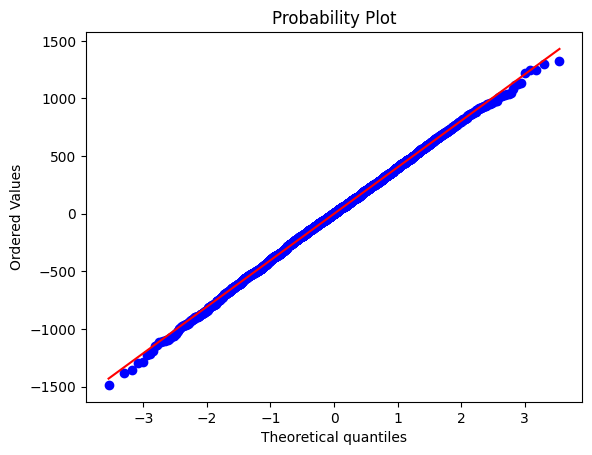

The residuals are normally distributed.


In [61]:
#Gaussianity
sw = stats.shapiro(results_3.resid).pvalue
print(f'Shapiro-Wilk test p-value: {sw:.4f}')

stats.probplot(results.resid, dist="norm", plot=plt)
plt.show()
if sw > 0.05:
    print("The residuals are normally distributed.")
else:
    print("The residuals are not normally distributed.")

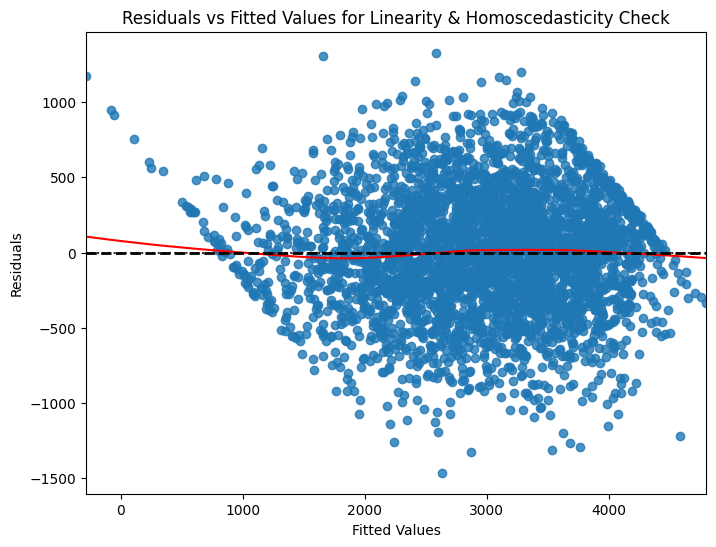

p-value: 0.4241537981282003
The residuals are homoscedastic.


In [62]:
#Linearity and Omoschedasticity

fitted_vals = results_3.fittedvalues
residuals = results_3.resid

plt.figure(figsize=(8, 6))
sns.residplot(x=fitted_vals, y=residuals, lowess=True,
              line_kws={'color': 'red', 'lw': 1.5})  # Add a smooth trendline

plt.axhline(0, color='black', linestyle='--', lw=2)  # Horizontal line at 0
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values for Linearity & Homoscedasticity Check')
plt.show()

bp_test = het_breuschpagan(results_3.resid, X_train_3_scaled)
print(f'p-value: {bp_test[1]}')
if bp_test[1] < 0.05:
    print("The residuals are not homoscedastic.")
else:
    print("The residuals are homoscedastic.")


In [63]:
#Collinearity

data = X_train_3_scaled

vif_data = pd.DataFrame()
vif_data["Variable"] = data.columns

vif_data["VIF"] = [variance_inflation_factor(data.values, i) for i in range(data.shape[1])]

print(vif_data)

                              Variable  VIF
0                                const 3.85
1  Residential_distance_to_green_space 1.03
2   Residential_distance_to_blue_space 1.08
3                                  NO2 3.63
4                             NO2_PM25 3.75
5     Accessibility_to_green_space_Yes 1.01


### Leverages & outliers

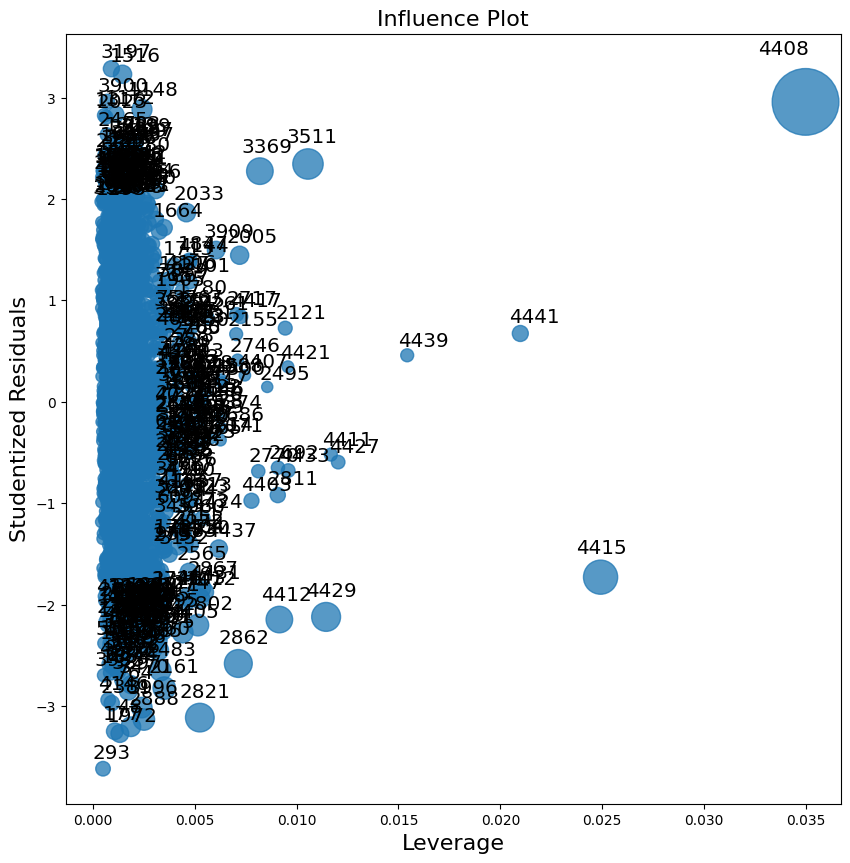

In [64]:
fig, ax = plt.subplots(figsize=(10,10))
sm.graphics.influence_plot(results_3, criterion="cooks", ax=ax);


In [65]:
#Remove outlier and leverage
X_train_4 = X_train_3_scaled.drop([4408, 3511, 3369, 4415, 4441])
y_train_4 = y_train_3.drop([4408, 3511, 3369, 4415, 4441])
X_test_4 = X_test_3_scaled
y_test_4 = y_test_3

## Final model (fixed effects)

In [66]:
models, best_features = best_subset_selection(X_train_4, y_train_4, selection_criterion='adj_r2')
print(models)

  0%|          | 0/6 [00:00<?, ?it/s]

   n_features                                           features      aic  \
4           5  [Residential_distance_to_green_space, Resident... 52705.84   
5           6  [const, Residential_distance_to_green_space, R... 52705.84   
3           4  [Residential_distance_to_green_space, Resident... 52722.05   
2           3  [Residential_distance_to_green_space, Resident... 52754.21   
1           2  [Residential_distance_to_green_space, Resident... 53772.95   
0           1              [Residential_distance_to_green_space] 56042.25   

       bic  adj_r2   cp  
4 52742.89    0.78 6.00  
5 52742.89    0.78 6.00  
3 52752.93    0.78 5.00  
2 52778.91    0.78 4.00  
1 53791.47    0.71 3.00  
0 56054.60    0.45 2.00  


In [67]:
best_model = models.iloc[0]
print(best_model)

n_features                                                    5
features      [Residential_distance_to_green_space, Resident...
aic                                                    52705.84
bic                                                    52742.89
adj_r2                                                     0.78
cp                                                         6.00
Name: 4, dtype: object


In [68]:
model = sm.OLS(y_train_4, X_train_4)
results_4 = model.fit()
print(results_4.summary())

y_pred = results_4.predict(X_test_4)
r2 = r2_score(y_test_4,y_pred)
mse = mean_squared_error(y_test_4,y_pred)
n = len(y_test_4)
p = X_test_4.shape[1]
adj_r2 = 1 - (1 - r2) * (n - 1) / (n - p - 1)
print(f'R2: {r2:.4f}')
print(f'adj_R2: {adj_r2:.4f}')
print(f'MSE: {mse:.4f}')

                              OLS Regression Results                             
Dep. Variable:     Birth_weight_modelled   R-squared:                       0.787
Model:                               OLS   Adj. R-squared:                  0.787
Method:                    Least Squares   F-statistic:                     2622.
Date:                   Mon, 02 Dec 2024   Prob (F-statistic):               0.00
Time:                           17:18:17   Log-Likelihood:                -26347.
No. Observations:                   3551   AIC:                         5.271e+04
Df Residuals:                       3545   BIC:                         5.274e+04
Df Model:                              5                                         
Covariance Type:               nonrobust                                         
                                          coef    std err          t      P>|t|      [0.025      0.975]
----------------------------------------------------------------------------

In [69]:
#Independence
durbin_watson(results_4.resid)

2.03803991607354

Shapiro-Wilk test p-value: 0.2426


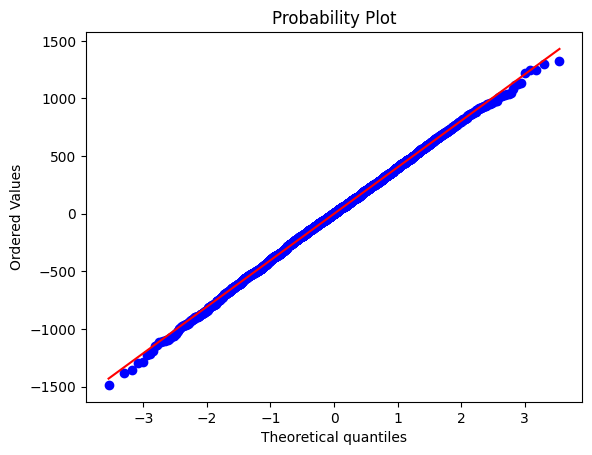

The residuals are normally distributed.


In [70]:
#Gaussianity
sw = stats.shapiro(results_4.resid).pvalue
print(f'Shapiro-Wilk test p-value: {sw:.4f}')

stats.probplot(results.resid, dist="norm", plot=plt)
plt.show()
if sw > 0.05:
    print("The residuals are normally distributed.")
else:
    print("The residuals are not normally distributed.")

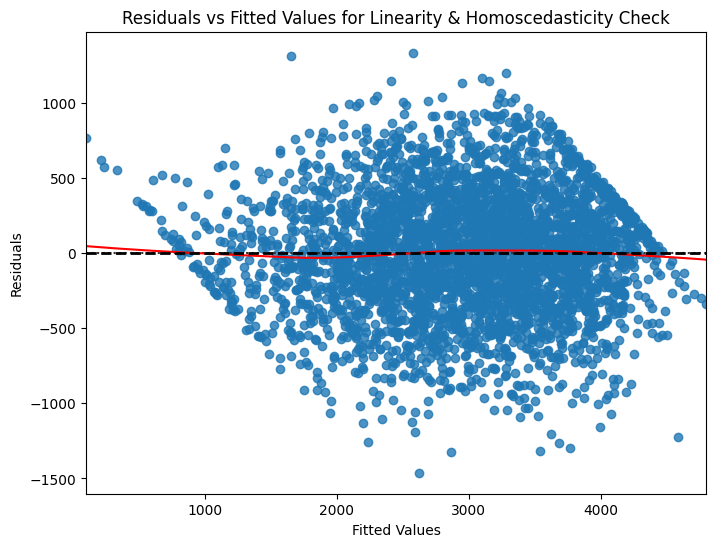

p-value: 0.4241537981282003
The residuals are homoscedastic.


In [71]:
#Linearity and Omoschedasticity

fitted_vals = results_4.fittedvalues
residuals = results_4.resid

plt.figure(figsize=(8, 6))
sns.residplot(x=fitted_vals, y=residuals, lowess=True,
              line_kws={'color': 'red', 'lw': 1.5})  # Add a smooth trendline

plt.axhline(0, color='black', linestyle='--', lw=2)  # Horizontal line at 0
plt.xlabel('Fitted Values')
plt.ylabel('Residuals')
plt.title('Residuals vs Fitted Values for Linearity & Homoscedasticity Check')
plt.show()

bp_test = het_breuschpagan(results_3.resid, X_train_3_scaled)
print(f'p-value: {bp_test[1]}')
if bp_test[1] < 0.05:
    print("The residuals are not homoscedastic.")
else:
    print("The residuals are homoscedastic.")

In [72]:
#Collinearity

data = X_train_4

vif_data = pd.DataFrame()
vif_data["Variable"] = data.columns

vif_data["VIF"] = [variance_inflation_factor(data.values, i) for i in range(data.shape[1])]

print(vif_data)

                              Variable  VIF
0                                const 3.85
1  Residential_distance_to_green_space 1.03
2   Residential_distance_to_blue_space 1.09
3                                  NO2 3.64
4                             NO2_PM25 3.78
5     Accessibility_to_green_space_Yes 1.01


## Generalized linear mixed model

In [73]:
#Fitting a Generalized Linear Mixed Model with Cohort Random Effects
X_train_5 = X_train_4.copy()
y_train_5 = y_train_4.copy()
X_test_5 = X_test_4.copy()
y_test_5 = y_test_4.copy()

train_indexes = X_train_5.index.copy()
test_indexes = X_test_5.index.copy()

groups = df.loc[train_indexes, 'Cohort']
glmm_model = gpb.GPModel(group_data=groups, likelihood='gaussian')
glmm_model.fit(y=y_train_5, X=X_train_5, params={"std_dev": True})
glmm_model.summary()


Model summary:
  Log-lik      AIC      BIC
-26315.33 52646.66 52696.06
Nb. observations: 3551
Nb. groups: 11 (Cohort)
-----------------------------------------------------
Covariance parameters (random effects):
              Param.  Std. dev.
Error_term 159147.30    3782.56
Cohort       3743.49    1956.19
-----------------------------------------------------
Linear regression coefficients (fixed effects):
                                     Param.  Std. dev.  z value  P(>|z|)
const                               3005.60      24.24   123.98     0.00
Residential_distance_to_green_space -644.28       7.11   -90.64     0.00
Residential_distance_to_blue_space  -490.27       8.04   -61.00     0.00
NO2                                 -199.08      17.12   -11.63     0.00
NO2_PM25                             -77.79      20.35    -3.82     0.00
Accessibility_to_green_space_Yes     -63.40      15.51    -4.09     0.00


In [74]:
all_training_data_random_effects = glmm_model.predict_training_data_random_effects()
first_occurences = [np.where(groups==i)[0][0] for i in np.unique(groups)]
training_data_random_effects = all_training_data_random_effects.iloc[first_occurences]
training_data_random_effects

,Cohort
1,-18.05
8,116.40
6,101.40
0,21.06
12,-33.03
3,-37.07
2,-24.01
36,-11.67
7,-19.42
4,-48.10


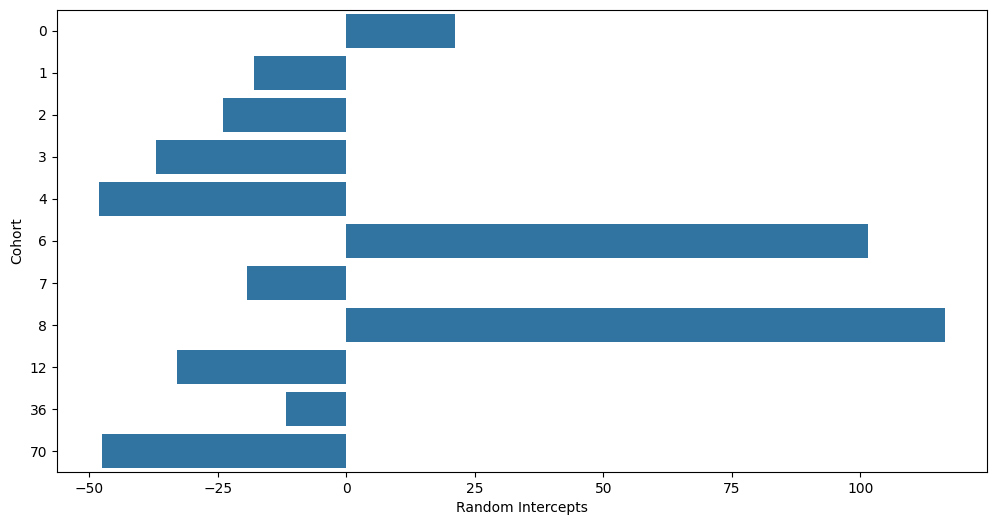

In [75]:
df_random_effects = training_data_random_effects.reset_index()
df_random_effects.columns = ["Cohort", "random_intercept"]
df_random_effects = df_random_effects.sort_values(by='Cohort')
# Set 'Cohort' as an ordered categorical variable to ensure plot respects this order
df_random_effects["Cohort"] = pd.Categorical(df_random_effects["Cohort"], categories=df_random_effects["Cohort"], ordered=True)
plt.figure(figsize=(12, 6))
sns.barplot(data=df_random_effects, y='Cohort', x='random_intercept')
plt.xlabel("Random Intercepts")
plt.ylabel("Cohort")
plt.show()


# **Logistic Model for Preterm**

## Model with only numerical variables

Optimization terminated successfully.
         Current function value: 0.423130
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:               Pre_term   No. Observations:                 3556
Model:                          Logit   Df Residuals:                     3549
Method:                           MLE   Df Model:                            6
Date:                Mon, 02 Dec 2024   Pseudo R-squ.:                  0.3728
Time:                        17:18:28   Log-Likelihood:                -1504.6
converged:                       True   LL-Null:                       -2399.0
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
Maternal_age                           -0.1182      0.007 

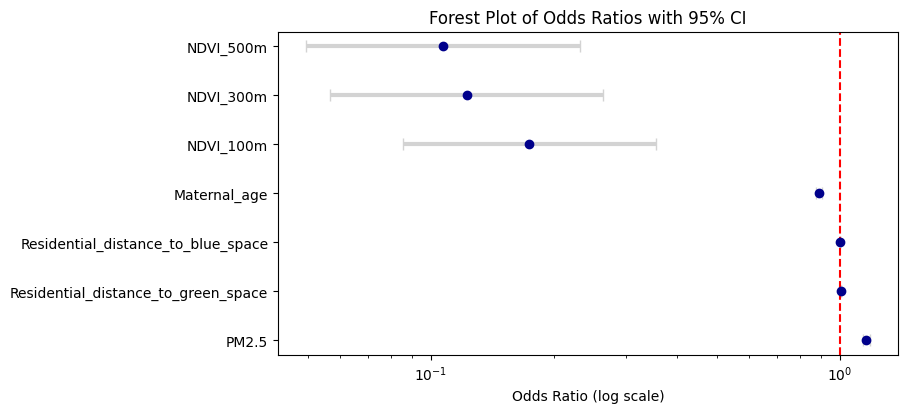

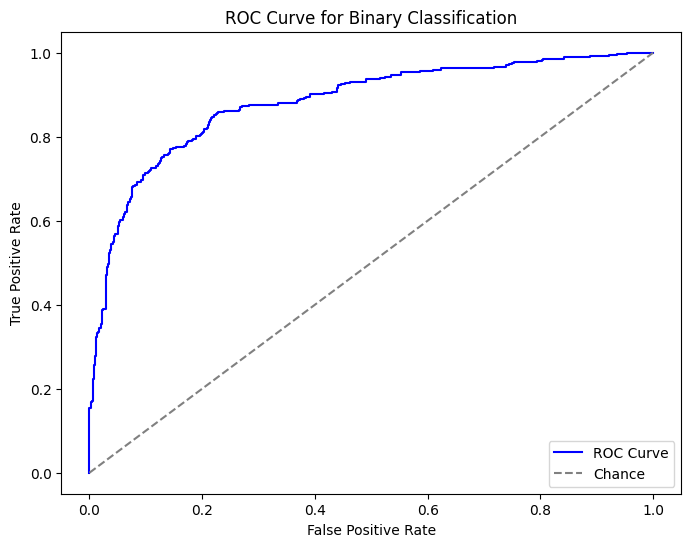

ROC-AUC Score on Test Set: 0.8819178714080534


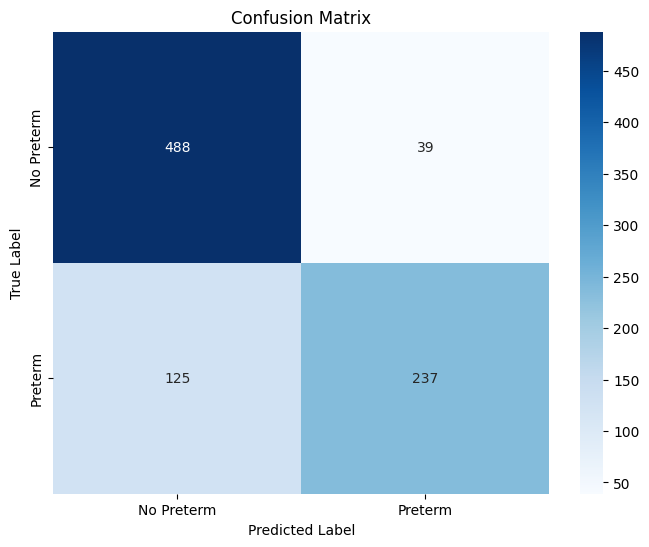


Classification Report on Test Set:
              precision    recall  f1-score   support

  No Preterm       0.80      0.93      0.86       527
     Preterm       0.86      0.65      0.74       362

    accuracy                           0.82       889
   macro avg       0.83      0.79      0.80       889
weighted avg       0.82      0.82      0.81       889

Specificity on Test Set: 0.9259962049335864


In [76]:
Xlo = df[['Maternal_age', 'NDVI_100m', 'NDVI_300m', 'NDVI_500m', 'Residential_distance_to_green_space',
          'Residential_distance_to_blue_space', 'PM2.5']]
ylo = df['Pre_term']
Xlo_train, Xlo_test, ylo_train, ylo_test = train_test_split(Xlo, ylo, test_size=0.20, random_state=1234)
train_index = Xlo_train.index
test_index = Xlo_test.index

# Fit the logistic regression model
logit_model = sm.Logit(ylo_train, Xlo_train).fit()
print(logit_model.summary())

#Coefficients
coef = logit_model.params
odds_ratios = np.exp(coef)
conf = logit_model.conf_int()
conf.columns = ['2.5%', '97.5%']
conf = np.exp(conf)  # Exponentiate to get ORs' CIs
or_summary = pd.DataFrame({
    "Coefficient": coef,
    "Odds Ratio": odds_ratios,
    "2.5% CI OR": conf['2.5%'],
    "97.5% CI OR": conf['97.5%']
})
print(or_summary)

# Sort by odds ratio for better visualization
or_summary = or_summary.sort_values(by="Odds Ratio", ascending=False)
# Set up the plot
fig, ax = plt.subplots(figsize=(8, len(or_summary) * 0.6))
ax.errorbar(or_summary['Odds Ratio'], or_summary.index,
            xerr=[or_summary['Odds Ratio'] - or_summary['2.5% CI OR'], or_summary['97.5% CI OR'] - or_summary['Odds Ratio']],
            fmt='o', color='darkblue', ecolor='lightgray', elinewidth=3, capsize=4)
ax.axvline(1, color='red', linestyle='--')
ax.set_xlabel("Odds Ratio (log scale)")
ax.set_title("Forest Plot of Odds Ratios with 95% CI")
ax.set_xscale("log")  # Log scale for better visualization
# Show plot
plt.show()

y_test_pred_prob = logit_model.predict(Xlo_test)

# Plot the ROC Curve
fpr, tpr, _ = roc_curve(ylo_test, y_test_pred_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f"ROC Curve")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Binary Classification")
plt.legend(loc="lower right")
plt.show()

auc_score = roc_auc_score(ylo_test, y_test_pred_prob)
print(f"ROC-AUC Score on Test Set: {auc_score}")

# Convert probabilities to binary outcomes
optimal_threshold = 1 - df['Pre_term'].mean() # 1 - % of positive samples
y_test_pred_class = (y_test_pred_prob > optimal_threshold).astype(int)
cm = confusion_matrix(ylo_test, y_test_pred_class)
class_names = ['No Preterm', 'Preterm']
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

#Classification Report
print("\nClassification Report on Test Set:")
print(classification_report(ylo_test, y_test_pred_class, target_names=['No Preterm', 'Preterm']))
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
print(f"Specificity on Test Set: {specificity}")

## Model with numerical and categorical variables

In [77]:
#transform categorical variable with OneHotEncoder
cat_vars_1 = ['Parity', 'Pre_term', 'Child_sex',  'Maternal_education',  'Maternal_ethnicity',  'Area_level_deprivation', 'Maternal_smoking', 'Maternal_alcohol_consumption', 'Accessibility_to_green_space', 'Accessibility_to_blue_space']
encoder = OneHotEncoder(drop='first', sparse_output=False)
encoded_feature = encoder.fit_transform(df[cat_vars_1])
df_encoded_1 = pd.DataFrame(encoded_feature, columns=encoder.get_feature_names_out(cat_vars_1))
df_encoded_1 = pd.concat([df.drop(cat_vars_1, axis=1), df_encoded_1], axis=1)
df_encoded_1

,Maternal_age,NDVI_100m,NDVI_300m,NDVI_500m,Residential_distance_to_green_space,Residential_distance_to_blue_space,NO2,PM2.5,Birth_weight_modelled,Cohort,...,Child_sex_Girl,Maternal_education_Low,Maternal_education_Medium,Maternal_ethnicity_Western,Area_level_deprivation_Low,Area_level_deprivation_Medium,Maternal_smoking_Yes,Maternal_alcohol_consumption_Yes,Accessibility_to_green_space_Yes,Accessibility_to_blue_space_Yes
0,28.03,0.54,0.32,0.49,365.20,1051.50,38.81,18.80,2057.19,A,...,0.00,0.00,0.00,1.00,1.00,0.00,1.00,1.00,1.00,0.00
1,37.09,0.27,0.20,0.48,277.60,941.83,23.79,14.35,3036.11,A,...,1.00,0.00,1.00,0.00,1.00,0.00,0.00,0.00,1.00,0.00
2,32.34,0.39,0.48,0.34,289.12,2334.22,25.14,17.32,1680.52,A,...,1.00,0.00,0.00,1.00,0.00,1.00,0.00,0.00,1.00,0.00
3,30.65,0.39,0.58,0.55,159.52,1154.24,30.66,12.42,3280.88,A,...,0.00,0.00,0.00,1.00,1.00,0.00,0.00,0.00,1.00,1.00
4,24.86,0.37,0.28,0.29,394.88,1798.14,22.26,15.76,2296.78,A,...,0.00,0.00,1.00,1.00,1.00,0.00,0.00,0.00,1.00,1.00
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4440,32.44,0.26,0.20,0.13,243.16,2399.25,24.25,25.12,2038.71,K,...,0.00,0.00,0.00,1.00,0.00,1.00,0.00,1.00,1.00,0.00
4441,31.27,-0.00,0.31,0.35,289.74,2713.54,63.22,29.43,842.00,K,...,1.00,0.00,1.00,0.00,0.00,0.00,0.00,1.00,1.00,0.00
4442,34.37,0.15,0.23,0.27,277.94,550.61,22.55,32.28,2592.87,K,...,0.00,0.00,1.00,1.00,0.00,1.00,0.00,1.00,1.00,0.00
4443,32.47,0.20,0.27,0.29,61.51,536.72,52.00,23.31,2428.95,K,...,0.00,0.00,1.00,1.00,1.00,0.00,0.00,0.00,1.00,0.00


In [78]:
print(df_encoded_1.columns)

Index(['Maternal_age', 'NDVI_100m', 'NDVI_300m', 'NDVI_500m',
       'Residential_distance_to_green_space',
       'Residential_distance_to_blue_space', 'NO2', 'PM2.5',
       'Birth_weight_modelled', 'Cohort', 'Parity_Single', 'Pre_term_1',
       'Child_sex_Girl', 'Maternal_education_Low', 'Maternal_education_Medium',
       'Maternal_ethnicity_Western', 'Area_level_deprivation_Low',
       'Area_level_deprivation_Medium', 'Maternal_smoking_Yes',
       'Maternal_alcohol_consumption_Yes', 'Accessibility_to_green_space_Yes',
       'Accessibility_to_blue_space_Yes'],
      dtype='object')


Optimization terminated successfully.
         Current function value: 0.354236
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:             Pre_term_1   No. Observations:                 3556
Model:                          Logit   Df Residuals:                     3542
Method:                           MLE   Df Model:                           13
Date:                Mon, 02 Dec 2024   Pseudo R-squ.:                  0.4749
Time:                        17:18:29   Log-Likelihood:                -1259.7
converged:                       True   LL-Null:                       -2399.0
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
const                                 -11.9972      0.665 

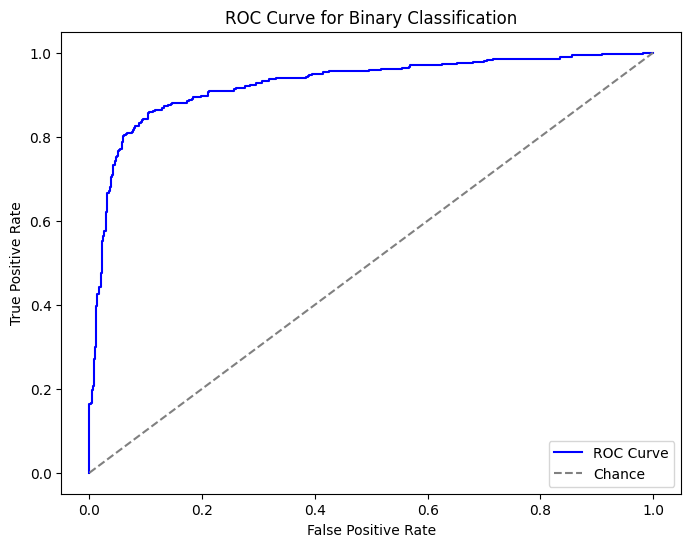

ROC-AUC Score on Test Set: 0.9255978277962406

Classification Report on Test Set:
              precision    recall  f1-score   support

  No Preterm       0.80      0.93      0.86       527
     Preterm       0.86      0.65      0.74       362

    accuracy                           0.82       889
   macro avg       0.83      0.79      0.80       889
weighted avg       0.82      0.82      0.81       889

Specificity on Test Set: 0.9259962049335864


In [79]:
num_variables = ['Maternal_age', 'NDVI_100m', 'NDVI_300m', 'NDVI_500m', 'Residential_distance_to_green_space', 'Residential_distance_to_blue_space', 'NO2', 'PM2.5']
cat_variables = ['Maternal_ethnicity_Western', 'Accessibility_to_blue_space_Yes', 'Accessibility_to_green_space_Yes', 'Maternal_alcohol_consumption_Yes', 'Area_level_deprivation_Low']

Xlo_1 = df_encoded_1[num_variables + cat_variables]
ylo_1 = df_encoded_1[['Pre_term_1']]
Xlo_train_1, Xlo_test_1, ylo_train_1, ylo_test_1 = train_test_split(Xlo_1, ylo_1, test_size=0.20, random_state=1234)

Xlo_train_1 = sm.add_constant(Xlo_train_1)
Xlo_test_1 = sm.add_constant(Xlo_test_1)

logit_model = sm.Logit(ylo_train_1, Xlo_train_1).fit()
print(logit_model.summary())

coef = logit_model.params
odds_ratios = np.exp(coef)
conf = logit_model.conf_int()
conf.columns = ['2.5%', '97.5%']
conf = np.exp(conf)
or_summary = pd.DataFrame({
    "Coefficient": coef,
    "Odds Ratio": odds_ratios,
    "2.5% CI OR": conf['2.5%'],
    "97.5% CI OR": conf['97.5%']
})
print(or_summary)

y_test_pred_prob = logit_model.predict(Xlo_test_1)

# Plot the ROC Curve
fpr, tpr, _ = roc_curve(ylo_test_1, y_test_pred_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f"ROC Curve")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Binary Classification")
plt.legend(loc="lower right")
plt.show()

auc_score = roc_auc_score(ylo_test_1, y_test_pred_prob)
print(f"ROC-AUC Score on Test Set: {auc_score}")
print("\nClassification Report on Test Set:")
print(classification_report(ylo_test_1, y_test_pred_class, target_names=['No Preterm', 'Preterm']))
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
print(f"Specificity on Test Set: {specificity}")

## Model with Polynomial Features

Optimization terminated successfully.
         Current function value: 0.353718
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:             Pre_term_1   No. Observations:                 3556
Model:                          Logit   Df Residuals:                     3540
Method:                           MLE   Df Model:                           15
Date:                Mon, 02 Dec 2024   Pseudo R-squ.:                  0.4757
Time:                        17:18:30   Log-Likelihood:                -1257.8
converged:                       True   LL-Null:                       -2399.0
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
const                                 -10.9015      0.892 

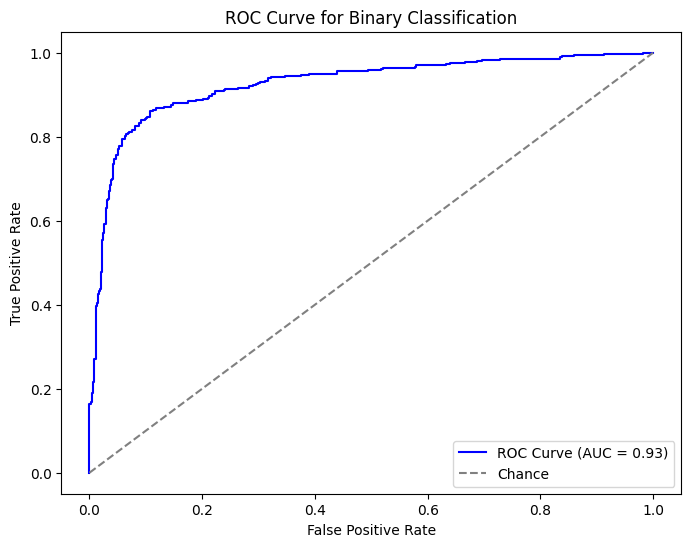

ROC-AUC Score on Test Set: 0.9255925859918017

Classification Report on Test Set:
              precision    recall  f1-score   support

  No Preterm       0.85      0.95      0.90       527
     Preterm       0.92      0.75      0.83       362

    accuracy                           0.87       889
   macro avg       0.88      0.85      0.86       889
weighted avg       0.88      0.87      0.87       889

Specificity on Test Set: 0.952561669829222


In [80]:
num_variables = [
    'Maternal_age', 'NDVI_100m', 'NDVI_300m', 'NDVI_500m',
    'Residential_distance_to_green_space', 'Residential_distance_to_blue_space',
    'NO2', 'PM2.5'
]
cat_variables = [
    'Maternal_ethnicity_Western', 'Accessibility_to_blue_space_Yes',
    'Accessibility_to_green_space_Yes', 'Maternal_alcohol_consumption_Yes',
    'Area_level_deprivation_Low'
]

df_encoded_1['NO2_PM25'] = df_encoded_1['NO2'] * df_encoded_1['PM2.5']
df_encoded_1['NDVI_Combination'] = (df_encoded_1['NDVI_100m'] * df_encoded_1['NDVI_300m'] * df_encoded_1['NDVI_500m'])
Xlo_2 = df_encoded_1[num_variables + cat_variables + ['NO2_PM25', 'NDVI_Combination']]
ylo_2 = df_encoded_1[['Pre_term_1']]

# Split train-test
Xlo_train_2, Xlo_test_2, ylo_train_2, ylo_test_2 = train_test_split(
    Xlo_2, ylo_2, test_size=0.20, random_state=1234
)

Xlo_train_2 = sm.add_constant(Xlo_train_2)
Xlo_test_2 = sm.add_constant(Xlo_test_2)

# Model
logit_model = sm.Logit(ylo_train_2, Xlo_train_2).fit()
print(logit_model.summary())

coef = logit_model.params
odds_ratios = np.exp(coef)
conf = logit_model.conf_int()
conf.columns = ['2.5%', '97.5%']
conf = np.exp(conf)
or_summary = pd.DataFrame({
    "Coefficient": coef,
    "Odds Ratio": odds_ratios,
    "2.5% CI OR": conf['2.5%'],
    "97.5% CI OR": conf['97.5%']
})
print(or_summary)

y_test_pred_prob = logit_model.predict(Xlo_test_2)

# ROC curve
fpr, tpr, _ = roc_curve(ylo_test_2, y_test_pred_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f"ROC Curve (AUC = {roc_auc_score(ylo_test_2, y_test_pred_prob):.2f})")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Binary Classification")
plt.legend(loc="lower right")
plt.show()

# AUC Score
auc_score = roc_auc_score(ylo_test_2, y_test_pred_prob)
print(f"ROC-AUC Score on Test Set: {auc_score}")

#Classification Report
optimal_threshold = 1 - df['Pre_term'].mean() # 1 - % of positive samples
y_test_pred_class = (y_test_pred_prob > optimal_threshold).astype(int)
print("\nClassification Report on Test Set:")
print(classification_report(ylo_test_2, y_test_pred_class, target_names=['No Preterm', 'Preterm']))

cm = confusion_matrix(ylo_test_2, y_test_pred_class)
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
print(f"Specificity on Test Set: {specificity}")

## Best subsect selection

In [81]:
def cp_score(model,n):
  p = len(model.params)
  rss = model.ssr
  mse_resid = model.mse_resid
  return rss / mse_resid - (n - 2 * p)
def adjusted_r2(y_true, y_pred, k):
    """Calculate Adjusted R^2."""
    n = len(y_true)
    r2 = 1 - (np.sum((y_true - y_pred) ** 2) / np.sum((y_true - np.mean(y_true)) ** 2))
    return 1 - ((1 - r2) * (n - 1)) / (n - k - 1)
from sklearn.model_selection import KFold
def cross_val_metrics(X, y, n_splits=10):
    """Calculate the adj r2 using cross-validation."""
    kf = KFold(n_splits=n_splits)
    scores = []
    for train_index, test_index in kf.split(X):
        X_train, X_test = X.iloc[train_index], X.iloc[test_index]
        y_train, y_test = y.iloc[train_index], y.iloc[test_index]
        X_train = sm.add_constant(X_train)
        X_test = sm.add_constant(X_test)
        model = sm.OLS(y_train, X_train).fit()
        y_pred = model.predict(X_test)
        # Calculate the metric for this fold
        k = len(model.params)  # Number of predictors including intercept
        score = adjusted_r2(y_test.values.ravel(), y_pred, k)  # Access values and ravel y_test
        scores.append(score)  # Append the score directly
    return np.mean(scores)  # Return the average score across all folds

from itertools import combinations
def best_subset_selection(X, y, selection_criterion='aic'):
    # Start with the full set of features
    initial_features = X.columns.tolist()
    # Store results for each model size
    metrics = []
    # Step 1: Iteratively add features
    for k in tqdm(range(1, len(initial_features) + 1)):
        best_features = None
        best_adj_r2 = -float("inf")  # Initialize for finding best model in this iteration
        best_model_metrics = {}
        # Step 2: Evaluate all remaining features
        for combo in combinations(initial_features, k):
            current_features = list(combo)
            X_current = sm.add_constant(X[current_features])
            model = sm.OLS(y, X_current).fit()
            y_pred = model.predict(X_current)
            # Update if this feature is the best so far
            if model.rsquared_adj > best_adj_r2:
                best_adj_r2 = model.rsquared_adj
                best_features = current_features
                best_model_metrics = {'adj_r2':cross_val_metrics(X[current_features], y), 'bic': model.bic, 'aic': model.aic, 'cp': cp_score(model, len(y))}
                best_model_metrics['features'] = best_features
        metrics.append(best_model_metrics)
    # Step 3: Select the single best model based on selection criterion
    best_criterion_value = float("inf") # +infinite
    best_features = None
    for m in metrics:
        if selection_criterion == 'aic':
            if m['aic'] < best_criterion_value:
                best_criterion_value = m['aic']
                best_features = m['features']
        elif selection_criterion == 'bic':
            if m['bic'] < best_criterion_value:
                best_criterion_value = m['bic']
                best_features = m['features']
        elif selection_criterion == 'adj_r2':
            if m['adj_r2'] > best_criterion_value:
                best_criterion_value = m['adj_r2']
                best_features = m['features']
        elif selection_criterion == 'cp':
            if m['cp'] < best_criterion_value:
                best_criterion_value = m['cp']
                best_features = m['features']
        else:
            raise ValueError(f"Invalid selection criterion: {selection_criterion}")
    ascending = False if selection_criterion == 'adj_r2' else True
    summary_df = pd.DataFrame(metrics).sort_values(by=selection_criterion, ascending=ascending)
    summary_df['n_features'] = summary_df['features'].apply(len)
    summary_df = summary_df[['n_features', 'features', 'aic', 'bic', 'adj_r2', 'cp']] #reorder cols
    return summary_df, best_features

In [82]:
logit_models, best_features = best_subset_selection(Xlo_train_2, ylo_train_2, selection_criterion='adj_r2')
print(logit_models)

  0%|          | 0/16 [00:00<?, ?it/s]

    n_features                                           features     aic  \
4            5  [Residential_distance_to_green_space, Resident... 2778.85   
3            4  [Residential_distance_to_green_space, Resident... 2788.97   
2            3  [Residential_distance_to_green_space, Resident... 2803.73   
5            6  [Residential_distance_to_green_space, Resident... 2778.22   
6            7  [Maternal_age, Residential_distance_to_green_s... 2778.45   
7            8  [Maternal_age, Residential_distance_to_green_s... 2779.15   
8            9  [Maternal_age, Residential_distance_to_green_s... 2780.06   
9           10  [const, Maternal_age, Residential_distance_to_... 2780.06   
10          11  [const, Maternal_age, Residential_distance_to_... 2781.42   
11          12  [const, Maternal_age, Residential_distance_to_... 2783.17   
12          13  [const, Maternal_age, NDVI_300m, Residential_d... 2785.00   
13          14  [const, Maternal_age, NDVI_100m, NDVI_300m, ND... 2786.89   

### Best model

In [83]:
best_model = logit_models.iloc[0]
print(best_model)
print(best_model['features'])

n_features                                                    5
features      [Residential_distance_to_green_space, Resident...
aic                                                     2778.85
bic                                                     2815.91
adj_r2                                                     0.46
cp                                                         6.00
Name: 4, dtype: object
['Residential_distance_to_green_space', 'Residential_distance_to_blue_space', 'NO2', 'PM2.5', 'Accessibility_to_blue_space_Yes']


Optimization terminated successfully.
         Current function value: 0.355845
         Iterations 7
                           Logit Regression Results                           
Dep. Variable:             Pre_term_1   No. Observations:                 3556
Model:                          Logit   Df Residuals:                     3550
Method:                           MLE   Df Model:                            5
Date:                Mon, 02 Dec 2024   Pseudo R-squ.:                  0.4725
Time:                        17:28:48   Log-Likelihood:                -1265.4
converged:                       True   LL-Null:                       -2399.0
Covariance Type:            nonrobust   LLR p-value:                     0.000
                                          coef    std err          z      P>|z|      [0.025      0.975]
-------------------------------------------------------------------------------------------------------
const                                 -10.8552      0.402 

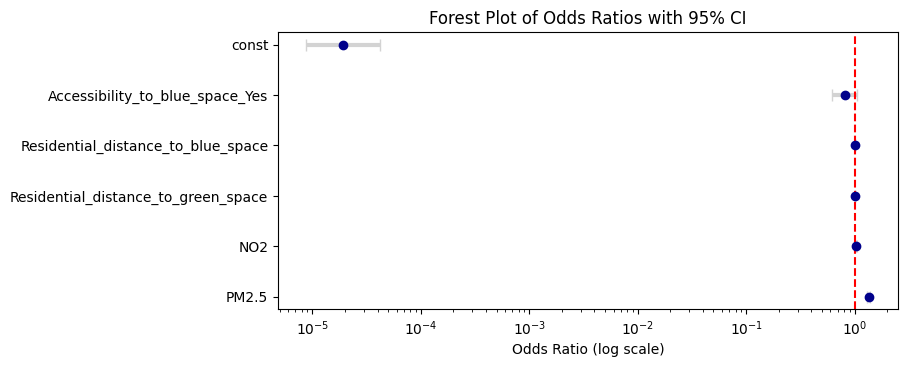

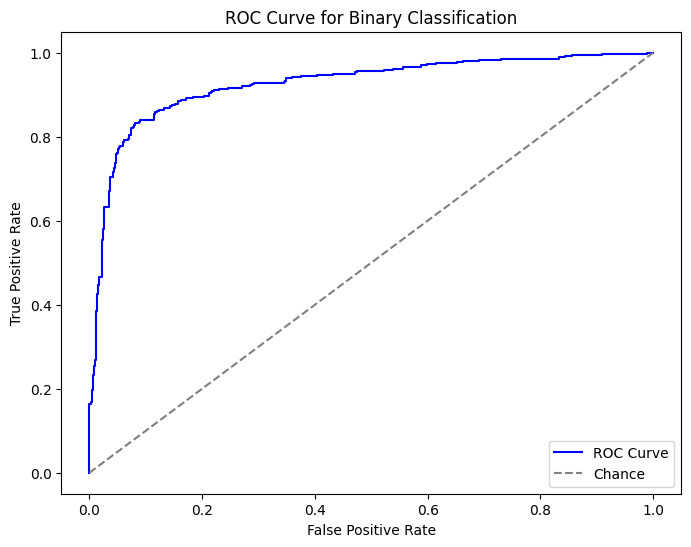

ROC-AUC Score on Test Set: 0.9251679998322622

Classification Report on Test Set:
              precision    recall  f1-score   support

  No Preterm       0.85      0.95      0.90       527
     Preterm       0.91      0.76      0.83       362

    accuracy                           0.87       889
   macro avg       0.88      0.86      0.86       889
weighted avg       0.88      0.87      0.87       889

Specificity on Test Set: 0.952561669829222


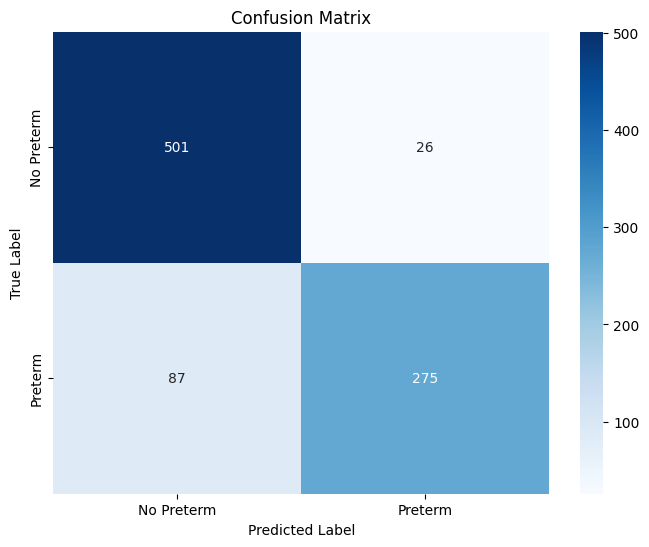

In [84]:
num_variables = ['Residential_distance_to_green_space', 'Residential_distance_to_blue_space', 'NO2', 'PM2.5']
cat_variables = ['Accessibility_to_blue_space_Yes']

Xlo_3 = df_encoded_1[num_variables + cat_variables]
ylo_3 = df_encoded_1[['Pre_term_1']]
Xlo_train_3, Xlo_test_3, ylo_train_3, ylo_test_3 = train_test_split(Xlo_3, ylo_3, test_size=0.20, random_state=1234)

Xlo_train_3 = sm.add_constant(Xlo_train_3)
Xlo_test_3 = sm.add_constant(Xlo_test_3)

logit_model = sm.Logit(ylo_train_3, Xlo_train_3).fit()
print(logit_model.summary())

coef = logit_model.params
odds_ratios = np.exp(coef)
conf = logit_model.conf_int()
conf.columns = ['2.5%', '97.5%']
conf = np.exp(conf)
or_summary = pd.DataFrame({
    "Coefficient": coef,
    "Odds Ratio": odds_ratios,
    "2.5% CI OR": conf['2.5%'],
    "97.5% CI OR": conf['97.5%']
})
print(or_summary)

or_summary = or_summary.sort_values(by="Odds Ratio", ascending=False)
fig, ax = plt.subplots(figsize=(8, len(or_summary) * 0.6))
ax.errorbar(or_summary['Odds Ratio'], or_summary.index,
            xerr=[or_summary['Odds Ratio'] - or_summary['2.5% CI OR'], or_summary['97.5% CI OR'] - or_summary['Odds Ratio']],
            fmt='o', color='darkblue', ecolor='lightgray', elinewidth=3, capsize=4)
ax.axvline(1, color='red', linestyle='--')
ax.set_xlabel("Odds Ratio (log scale)")
ax.set_title("Forest Plot of Odds Ratios with 95% CI")
ax.set_xscale("log")
plt.show()

y_test_pred_prob = logit_model.predict(Xlo_test_3)
optimal_threshold_1 = 1 - df['Pre_term'].mean() # 1 - % of positive samples
y_test_pred_class = (y_test_pred_prob > optimal_threshold_1).astype(int)

#ROC Curve
fpr, tpr, _ = roc_curve(ylo_test_3, y_test_pred_prob)
plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, color='blue', label=f"ROC Curve")
plt.plot([0, 1], [0, 1], color='gray', linestyle='--', label="Chance")
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve for Binary Classification")
plt.legend(loc="lower right")
plt.show()

#AUC and classification report
auc_score = roc_auc_score(ylo_test_3, y_test_pred_prob)
print(f"ROC-AUC Score on Test Set: {auc_score}")
print("\nClassification Report on Test Set:")
print(classification_report(ylo_test_3, y_test_pred_class, target_names=['No Preterm', 'Preterm']))

#Specificity
tn, fp, fn, tp = cm.ravel()
specificity = tn / (tn + fp)
print(f"Specificity on Test Set: {specificity}")

#Confusion Matrix
cm = confusion_matrix(ylo_test_2, y_test_pred_class)
class_names = ['No Preterm', 'Preterm']
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues", xticklabels=class_names, yticklabels=class_names)
plt.xlabel("Predicted Label")
plt.ylabel("True Label")
plt.title("Confusion Matrix")
plt.show()

### Multicollinearity

In [85]:
vif_data = pd.DataFrame()
vif_data['Variable'] = Xlo_train_3.columns
vif_data['VIF'] = [variance_inflation_factor(Xlo_train_3.values, i) for i in range(Xlo_train_3.shape[1])]
print ("Variance Inflation Factor (VIF):")
print(vif_data)

Variance Inflation Factor (VIF):
                              Variable   VIF
0                                const 25.09
1  Residential_distance_to_green_space  1.05
2   Residential_distance_to_blue_space  1.12
3                                  NO2  1.12
4                                PM2.5  1.12
5      Accessibility_to_blue_space_Yes  1.20


## Generalized linear mixed model

In [86]:
#Fitting a Generalized Linear Mixed Model with Cohort Random Effects
num_variables = ['Residential_distance_to_green_space', 'Residential_distance_to_blue_space', 'NO2', 'PM2.5']
cat_variables = ['Accessibility_to_blue_space_Yes']

Xlo_4 = df_encoded_1[num_variables + cat_variables]
ylo_4 = df_encoded_1[['Pre_term_1']]
Cohort = df_encoded_1['Cohort']

Xlo_train_4, Xlo_test_4, ylo_train_4, ylo_test_4, cohort_train, cohort_test = train_test_split(Xlo_4, ylo_4, Cohort, test_size=0.20, random_state=1234)

train_index = Xlo_train_4.index
test_index = Xlo_test_4.index

Xlo_train_4 = sm.add_constant(Xlo_train_4)
Xlo_test_4 = sm.add_constant(Xlo_test_4)

groups = cohort_train

glmm_model = gpb.GPModel(group_data=groups, likelihood="bernoulli_logit")
glmm_model.fit(y=ylo_train_4.values.ravel(), X=Xlo_train_4.values, params={"std_dev": True})


print(glmm_model.summary())

Model summary:
 Log-lik     AIC     BIC
-1260.97 2535.95 2579.18
Nb. observations: 3556
Nb. groups: 11 (Cohort)
-----------------------------------------------------
Covariance parameters (random effects):
        Param.
Cohort    0.04
-----------------------------------------------------
Linear regression coefficients (fixed effects):
             Param.  Std. dev.  z value  P(>|z|)
Covariate_1  -11.36       0.47   -24.41     0.00
Covariate_2    0.01       0.00    16.86     0.00
Covariate_3    0.00       0.00    27.40     0.00
Covariate_4    0.04       0.01     7.05     0.00
Covariate_5    0.31       0.02    16.56     0.00
Covariate_6   -0.14       0.15    -0.96     0.34


In [87]:
all_training_data_random_effects = glmm_model.predict_training_data_random_effects()
first_occurences = [np.where(groups==i)[0][0] for i in np.unique(groups)]
training_data_random_effects = all_training_data_random_effects.iloc[first_occurences]
training_data_random_effects

,Cohort
1,-0.12
8,-0.16
6,-0.19
0,0.06
12,0.10
3,-0.14
2,-0.03
36,-0.04
7,0.13
4,0.36


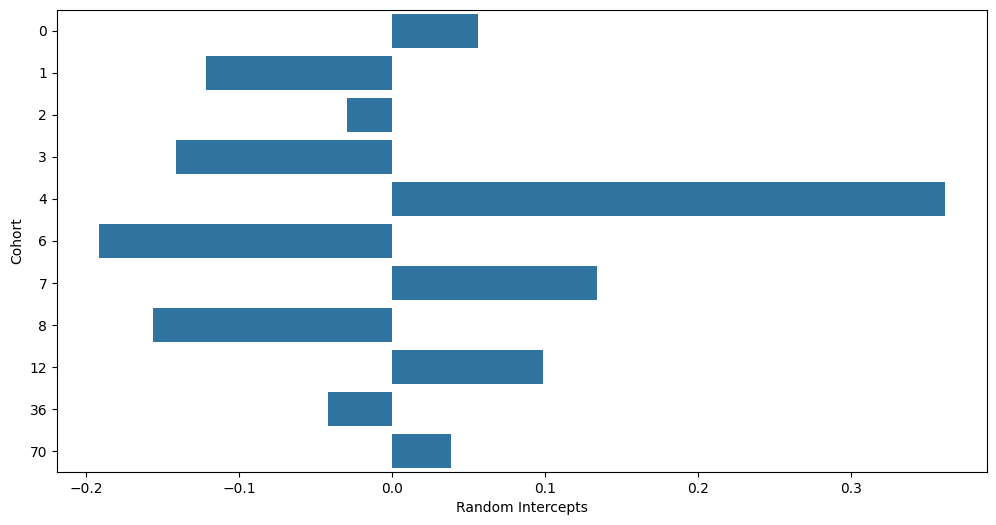

In [88]:
df_random_effects = training_data_random_effects.reset_index()
df_random_effects.columns = ["Cohort", "random_intercept"]
df_random_effects = df_random_effects.sort_values(by='Cohort')
df_random_effects["Cohort"] = pd.Categorical(df_random_effects["Cohort"], categories=df_random_effects["Cohort"], ordered=True)
plt.figure(figsize=(12, 6))
sns.barplot(data=df_random_effects, y='Cohort', x='random_intercept')
plt.xlabel("Random Intercepts")
plt.ylabel("Cohort")
plt.show()


In [89]:
# Make predictions on the test set
optimal_threshold_1 = 1 - df['Pre_term'].mean() # 1 - % of positive samples
y_pred_proba = glmm_model.predict(X_pred=Xlo_test_4, group_data_pred=df_encoded_1.loc[test_index, 'Cohort'], predict_response=True)['mu']  # Predict probabilities
y_pred = (y_pred_proba >= optimal_threshold_1).astype(int)  # Convert probabilities to binary predictions
# Confusion matrix
cm = confusion_matrix(ylo_test_4, y_pred)
print("Confusion Matrix:\n", cm)
# Classification report
class_report = classification_report(ylo_test_4, y_pred)
print("Classification Report:\n", class_report)
# ROC curve and AUC
fpr, tpr, thresholds = roc_curve(ylo_test_4, y_pred_proba)

auc_score = roc_auc_score(ylo_test_4, y_test_pred_prob)
print(f"ROC-AUC Score on Test Set: {auc_score}")
print("\nClassification Report on Test Set:")
print(classification_report(ylo_test_4, y_test_pred_class, target_names=['No Preterm', 'Preterm']))

Confusion Matrix:
 [[501  26]
 [ 90 272]]
Classification Report:
               precision    recall  f1-score   support

         0.0       0.85      0.95      0.90       527
         1.0       0.91      0.75      0.82       362

    accuracy                           0.87       889
   macro avg       0.88      0.85      0.86       889
weighted avg       0.87      0.87      0.87       889

ROC-AUC Score on Test Set: 0.9251679998322622

Classification Report on Test Set:
              precision    recall  f1-score   support

  No Preterm       0.85      0.95      0.90       527
     Preterm       0.91      0.76      0.83       362

    accuracy                           0.87       889
   macro avg       0.88      0.86      0.86       889
weighted avg       0.88      0.87      0.87       889

